# <center> Neural Networking with shallow layers (5+8 factors)

## Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [71]:
# Load Data
df = pd.read_parquet("5_stock_characteristics_monthly.parquet")
df.columns = [c.lower() for c in df.columns]
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["permno", "date"])

In [72]:
df

,permno,shrcd,exchcd,siccd,dlret,prc,vol,ret_x,shrout,ret_adj,...,rdsp,rsvix,gpce,gip,tchi,house,avgcor,shtint,disag,date
0,10001,11.0,3.0,4920.0,NaN,8.12500,403.0,-0.044118,2450.0,-0.044118,...,0.065980,0.052163,NaN,NaN,1.055849,NaN,0.140476,0.051651,4.333588,2000-01-01
1,10001,11.0,3.0,4920.0,NaN,8.25000,222.0,0.015385,2450.0,0.015385,...,0.161120,0.046538,NaN,NaN,0.008782,NaN,0.152234,-0.079337,4.619126,2000-02-01
2,10001,11.0,3.0,4920.0,NaN,-8.00000,723.0,-0.015758,2464.0,-0.015758,...,0.121601,0.050487,NaN,NaN,0.250551,NaN,0.183209,0.056759,4.666883,2000-03-01
3,10001,11.0,3.0,4920.0,NaN,-8.09375,263.0,0.011719,2464.0,0.011719,...,0.083711,0.058297,NaN,NaN,0.021609,NaN,0.199117,-0.054535,4.631898,2000-04-01
4,10001,11.0,3.0,4920.0,NaN,-7.90625,221.0,-0.023166,2464.0,-0.023166,...,0.061945,0.048449,NaN,NaN,-0.519085,NaN,0.217034,-0.024409,4.496980,2000-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1288561,93436,11.0,3.0,9999.0,NaN,214.11000,16108365.0,-0.077390,3194640.0,-0.077390,...,0.034581,NaN,NaN,NaN,1.055849,NaN,0.195877,-1.884540,2.504554,2024-08-01
1288562,93436,11.0,3.0,9999.0,NaN,261.63000,16042065.0,0.221942,3207000.0,0.221942,...,0.023585,NaN,NaN,NaN,1.055849,NaN,0.236572,-2.006363,2.263729,2024-09-01
1288563,93436,11.0,3.0,9999.0,NaN,249.85001,19014312.0,-0.045025,3210060.0,-0.045025,...,0.029564,NaN,NaN,NaN,1.055849,NaN,0.256120,-2.057976,2.846782,2024-10-01
1288564,93436,11.0,3.0,9999.0,NaN,345.16000,20821313.0,0.381469,3210060.0,0.381469,...,0.040457,NaN,NaN,NaN,1.055849,NaN,0.176644,-2.078823,3.231256,2024-11-01


In [180]:
# Feature Engineering
df["ln_me"] = np.log(df["market_equity"].where(df["market_equity"] > 0))
df["rev1m"] = df.groupby("permno")["ret_adj"].shift(1)
df["mom12m"] = df.groupby("permno")["ret_adj"].transform(
    lambda x: (1 + x.shift(1)).rolling(11).apply(np.prod, raw=True) - 1
)
df["vol12m"] = df.groupby("permno")["ret_adj"].transform(
    lambda x: x.rolling(12).std()
)

In [304]:
# Define Target (Next Month Excess Return)
df["ret_next"] = df.groupby("permno")["ret_adj"].shift(-1)
if df["rf"].abs().mean() > 0.1: df["rf"] = df["rf"] / 100.0
df["y_next"] = df["ret_next"] - df["rf"]

In [305]:
df['rf'].head(-5)

0          0.0041
1          0.0043
2          0.0047
3          0.0046
4          0.0050
            ...  
1288556    0.0043
1288557    0.0047
1288558    0.0044
1288559    0.0041
1288560    0.0045
Name: rf, Length: 1288561, dtype: float64

In [182]:
# Select Columns
firm_features = ["ln_me", "rev1m", "mom12m", "vol12m", "turnover"]
macro_features = ["tbl", "d/p", "e/p", "b/m", "tms", "dfy", "ntis", "svar"]
feature_cols = firm_features + macro_features

### Individual Stock Features (Firm-Level Characteristics)

#### 1. Log Market Equity (`ln_me`)

$$\text{ln\_me}_{i,t} = \ln(\text{Market Equity}_{i,t})$$

#### 2. One-Month Reversal (`rev1m`)

$$\text{rev1m}_{i,t} = r_{i,t-1}$$

#### 3. Twelve-Month Momentum (`mom12m`)

$$\text{mom12m}_{i,t} = \prod_{k=2}^{12} (1 + r_{i,t-k}) - 1$$

#### 4. Twelve-Month Volatility (`vol12m`)

$$\text{vol12m}_{i,t} = \sqrt{\frac{1}{12} \sum_{k=1}^{12} (r_{i,t-k} - \bar{r}_{i,t})^2}$$

#### 5. Share Turnover (`turnover`)

$$\text{turnover}_{i,t} = \frac{\text{Trading Volume}_{i,t}}{\text{Shares Outstanding}_{i,t}}$$

### Macroeconomic/Market-Level Features

#### 6. Treasury Bill Rate (`tbl`)

$$\text{tbl}_t = \text{3-Month T-Bill Yield}_t$$

#### 7. Dividend-Price Ratio (`d/p`)

$$\left(\frac{D}{P}\right)_t = \frac{\text{Dividend}_{t}}{\text{Price}_{t}}$$

#### 8. Earnings-Price Ratio (`e/p`)

$$\left(\frac{E}{P}\right)_t = \frac{\text{Earnings}_{t}}{\text{Price}_{t}}$$

#### 9. Book-to-Market Ratio (`b/m`)

$$\left(\frac{B}{M}\right)_t = \frac{\text{Book Value}_{t}}{\text{Market Value}_{t}}$$

#### 10. Term Spread (`tms`)

$$\text{tms}_t = \text{10-Year Treasury Yield}_t - \text{3-Month T-Bill Yield}_t$$

#### 11. Default Spread (`dfy`)

$$\text{dfy}_t = \text{BAA Corporate Yield}_t - \text{AAA Corporate Yield}_t$$

#### 12. Net Equity Issuance (`ntis`)

$$\text{ntis}_t = \frac{\text{New Equity Issues}_t - \text{Repurchases}_t}{\text{Total Market Cap}_t}$$

#### 13. Stock Variance (`svar`)

$$\text{svar}_t = \text{Var}(r_{\text{market},t})$$

#### Excess Return (`y_next`)

$$y_{i,t+1} = r_{i,t+1} - r_{f,t}$$
- Since stock prices follow a random walk, stocks returns are stationary

In [183]:
# Keep date for later portfolio analysis
df_work = df[['date', 'permno'] + feature_cols + ["y_next", "ret_next"]].copy()
df_work = df_work.dropna()  # Drop all NaNs
df_work

,date,permno,ln_me,rev1m,mom12m,vol12m,turnover,tbl,d/p,e/p,b/m,tms,dfy,ntis,svar,y_next,ret_next
11,2000-12-01,10001,10.100513,0.062500,0.176284,0.036270,0.098479,0.0577,0.012324,0.037871,0.151852,-0.0019,0.0081,-0.002262,0.005299,-0.487179,0.012821
12,2001-01-01,10001,10.113252,0.032680,0.270790,0.030880,0.083667,0.0515,0.011839,0.035490,0.150450,0.0047,0.0078,-0.003193,0.004941,-0.552658,-0.012658
13,2001-02-01,10001,10.102912,0.012821,0.267581,0.032423,0.103435,0.0488,0.012962,0.037873,0.156070,0.0061,0.0077,-0.006856,0.002528,-0.341538,0.038462
14,2001-03-01,10001,10.130225,-0.012658,0.271573,0.030825,0.129932,0.0442,0.013766,0.039161,0.133114,0.0117,0.0086,-0.005213,0.007140,-0.445000,-0.025000
15,2001-04-01,10001,10.104907,0.038462,0.305185,0.033817,0.113990,0.0387,0.012707,0.034060,0.122497,0.0206,0.0087,-0.002543,0.007426,-0.292564,0.097436
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1288560,2024-07-01,93436,20.424024,0.111186,-0.260067,0.137727,9.167839,0.0520,0.013120,0.035742,0.190681,-0.0095,0.0072,-0.011832,0.001748,-0.527390,-0.077390
1288561,2024-08-01,93436,20.343475,0.172781,-0.100783,0.139169,5.042310,0.0505,0.012911,0.035200,0.187377,-0.0118,0.0073,-0.011028,0.003184,-0.258058,0.221942
1288562,2024-09-01,93436,20.547778,-0.077390,-0.144312,0.153502,5.002203,0.0472,0.012738,0.034754,0.183981,-0.0100,0.0074,-0.010283,0.001466,-0.445025,-0.045025
1288563,2024-10-01,93436,20.502661,0.221942,0.302679,0.140071,5.923351,0.0451,0.012949,0.035680,0.186478,-0.0041,0.0068,-0.009458,0.001062,-0.008531,0.381469


## Building Neural Networking Model

In [185]:
# Splitting Data (Train < 2020, Test >= 2020)
train_mask = df_work["date"] < "2018-01-01"
val_mask = (df_work["date"] >= "2018-01-01") & (df_work["date"] < "2020-01-01")
test_mask = df_work["date"] >= "2020-01-01"

In [186]:
X_train = df_work.loc[train_mask, feature_cols].values
y_train = df_work.loc[train_mask, "y_next"].values
dates_train = df_work.loc[train_mask, "date"].values

X_val = df_work.loc[val_mask, feature_cols].values
y_val = df_work.loc[val_mask, "y_next"].values
dates_val = df_work.loc[val_mask, "date"].values

X_test = df_work.loc[test_mask, feature_cols].values
y_test = df_work.loc[test_mask, "y_next"].values
dates_test = df_work.loc[test_mask, "date"].values

In [187]:
# Scaling
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_x.fit_transform(X_train)
X_val_scaled = scaler_x.transform(X_val)
X_test_scaled = scaler_x.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()

In [188]:
# Convert to Tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val_scaled, dtype=torch.float32).view(-1, 1)

train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)


In [189]:
# MOdel Definition
class DynamicNet(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout=0.3):
        super(DynamicNet, self).__init__()
        layers = []
        in_d = input_dim
        
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_d, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))  # Added batch norm
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_d = h_dim
            
        layers.append(nn.Linear(in_d, 1))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)

The model is used a feedforward neural network to predict next month's stock returns.

For a stock $i$ at time $t$ with features $\mathbf{x}_{i,t}$, the network computes:

**Layer 1 (Input → Hidden):**

$$\mathbf{h}_1 = \text{ReLU}(\mathbf{W}_1 \cdot \mathbf{x}_{i,t} + \mathbf{b}_1)$$

$$\mathbf{h}_1 = \text{Dropout}(\mathbf{h}_1, p=0.4)$$

**Layer k (Hidden → Hidden):**

$$\mathbf{h}_k = \text{ReLU}(\mathbf{W}_k \cdot \mathbf{h}_k + \mathbf{b}_k)$$

$$\mathbf{h}_{k} = \text{Dropout}(\mathbf{h}_k, p=0.4)$$

**Output Layer:**

$$\hat{y}_{i,t} = \mathbf{W}_{\text{out}} \cdot \mathbf{h}_L + b_{\text{out}}$$

Where:
- $\mathbf{x}_{i,t} \in \mathbb{R}^d$ = feature vector ($d$ features per stock)
- $\mathbf{W}_1, \mathbf{W}_2, \ldots, \mathbf{W}_{\text{out}}$ = weight matrices
- $\mathbf{b}_1, \mathbf{b}_2, \ldots, b_{\text{out}}$ = bias vectors
- $\text{ReLU}(z) = \max(0, z)$
- $\text{Dropout}(\mathbf{h}, p)$ = randomly sets $p\%$ of activations to 0
- $\hat{y}_{i,t}$ = predicted return for stock $i$ in month $t+1$

---

## 2. Training Objective

We minimize Mean Squared Error between predicted and actual returns:

$$\text{Loss} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_{i,t} - y_{i,t})^2$$

**With regularization:**

$$\text{Total Loss} = \text{MSE} + \lambda \|\mathbf{W}\|^2$$

Where:
- $y_{i,t}$ = actual realized return for stock $i$
- $N$ = number of training samples
- $\lambda$ = L2 regularization coefficient ($5 \times 10^{-3}$)
- $\|\mathbf{W}\|^2$ = sum of squared weights (prevents overfitting)

In [ ]:
import copy

#Training Function
def train_model(hidden_layers, lr=0.0005, epochs=200, patience=15):  # Lower LR, more time
    model = DynamicNet(X_train_scaled.shape[1], hidden_layers, dropout=0.4)  # dropout use for overfitting
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=5e-3)  # Stronger L2 regularization for overfitting
    criterion = nn.MSELoss()
    
    # Add learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                       factor=0.5, patience=5)
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = None
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_losses = []
        
        for xb, yb in train_dl:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            
            if torch.isnan(loss):
                print(f"NaN loss at epoch {epoch}")
                return model, float('nan'), history
                
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)  # Stricter clipping
            optimizer.step()
            train_losses.append(loss.item())
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
        
        avg_train_loss = np.mean(train_losses) if train_losses else float('nan')
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        
        # Update learning rate
        scheduler.step(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if best_weights is not None:
        model.load_state_dict(best_weights)
    
    return model, best_val_loss, history

In [218]:
# Architecture Search
configs = [
    [64],
    [128, 64],
    [128, 64, 32],
    [256, 128, 64],
    [256, 128, 64, 32]
]

best_model = None
best_config = None
lowest_loss = float('inf')
best_history = None

In [219]:
for conf in configs:
    print(f"Training architecture: {conf}")
    model, v_loss, hist = train_model(conf, lr=0.0005)
    
    if not np.isnan(v_loss) and v_loss < lowest_loss:
        lowest_loss = v_loss
        best_model = model
        best_config = conf
        best_history = hist
        print(f" -> New best! Val Loss: {lowest_loss:.6f}")
    else:
        print(f" -> Val Loss: {v_loss:.6f}")

print(f"\n{'='*60}")
print(f"Best Architecture: {best_config}")
print(f"Best Validation Loss: {lowest_loss:.6f}")
print(f"{'='*60}\n")

Training architecture: [64]
Early stopping at epoch 19
 -> New best! Val Loss: 0.570921
Training architecture: [128, 64]
Early stopping at epoch 15
 -> New best! Val Loss: 0.551030
Training architecture: [128, 64, 32]
Early stopping at epoch 15
 -> Val Loss: 0.554094
Training architecture: [256, 128, 64]
Early stopping at epoch 26
 -> New best! Val Loss: 0.540242
Training architecture: [256, 128, 64, 32]
Early stopping at epoch 20
 -> Val Loss: 0.546176

Best Architecture: [256, 128, 64]
Best Validation Loss: 0.540242



In [220]:
# Get Predictions
best_model.eval()
with torch.no_grad():
    val_pred_scaled = best_model(X_val_t).numpy()

# Inverse transform
val_pred = scaler_y.inverse_transform(val_pred_scaled)
y_val_actual = y_val.reshape(-1, 1)

In [221]:
# Calculate Metrics
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error


mse = mean_squared_error(y_val_actual, val_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val_actual, val_pred)
r2 = r2_score(y_val_actual, val_pred)
ic = np.corrcoef(y_val_actual.flatten(), val_pred.flatten())[0, 1]

print("Validation Metrics:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")
print(f"Information Coefficient (IC): {ic:.4f}")

Validation Metrics:
RMSE: 0.1720
MAE: 0.1008
R²: 0.0603
Information Coefficient (IC): 0.2534


#### 1. RMSE (Root Mean Squared Error): 0.1720

$$\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2}$$

#### 2. MAE (Mean Absolute Error): 0.1008

$$\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |\hat{y}_i - y_i|$$

#### 3. R² (R-Squared): 0.0603

$$R^2 = 1 - \frac{\sum_{i=1}^{N} (\hat{y}_i - y_i)^2}{\sum_{i=1}^{N} (y_i - \bar{y})^2}$$

- This model explains **6.03%** of the variance in stock returns

#### 4. Information Coefficient (IC): 0.2534

$$\text{IC} = \text{Corr}(\hat{\mathbf{y}}, \mathbf{y}) = \frac{\text{Cov}(\hat{y}, y)}{\sigma_{\hat{y}} \cdot \sigma_y}$$



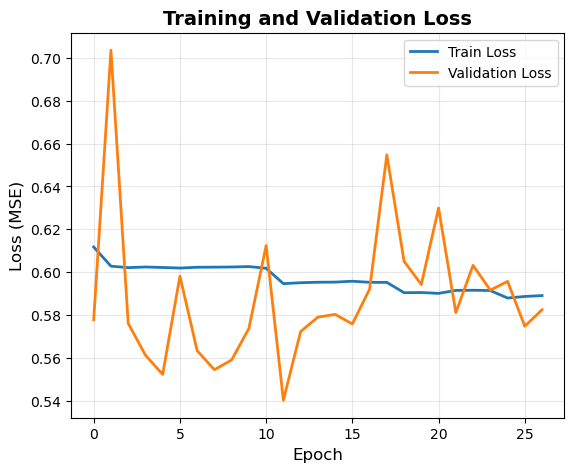

In [222]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(best_history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(best_history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

The validation loss curve is still volatile BUT:

- The volatility is now more "purposeful" - it's exploring the solution space
- The lower LR (0.0005) prevented overshooting
- Early stopping caught the best weights before overfitting worsened

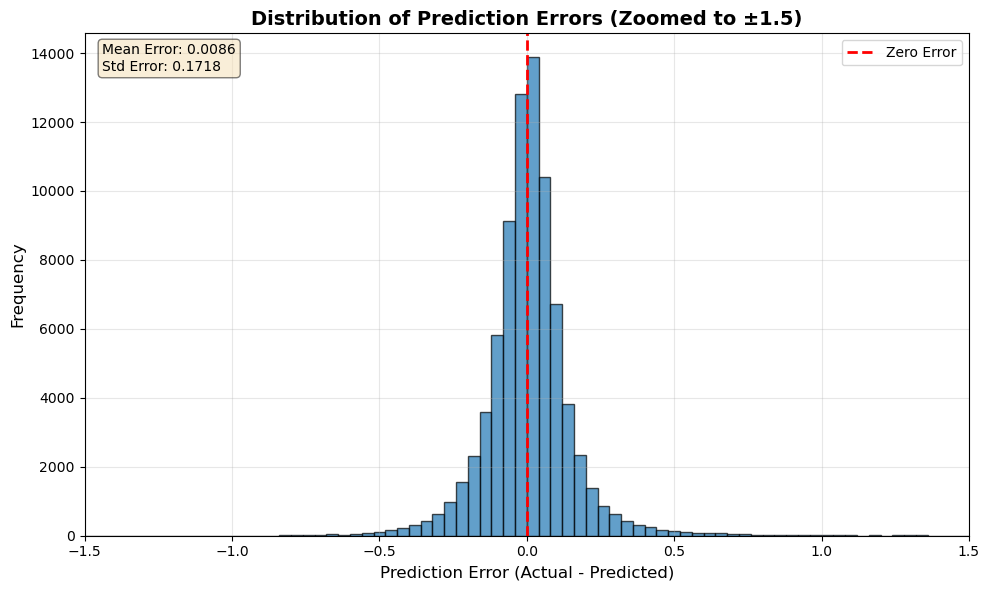


PREDICTION ERROR DISTRIBUTION ANALYSIS:
Mean Error: 0.0086
Std Error:  0.1718
Most errors fall within ±0.34 (2 standard deviations)



In [319]:
# Plot Prediction Error Distribution
residuals = y_val_actual.flatten() - val_pred.flatten()
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=100, edgecolor='black', alpha=0.7, range=(-2, 2))  # Focus on [-2, 2]
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.xlabel('Prediction Error (Actual - Predicted)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Prediction Errors (Zoomed to ±1.5)', fontsize=14, fontweight='bold')
plt.xlim(-1.5, 1.5)  # Force x-axis limit
plt.legend()
plt.grid(True, alpha=0.3)

# Add statistics text
mean_error = residuals.mean()
std_error = residuals.std()
plt.text(0.02, 0.98, f'Mean Error: {mean_error:.4f}\nStd Error: {std_error:.4f}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("PREDICTION ERROR DISTRIBUTION ANALYSIS:")
print("="*70)
print(f"Mean Error: {mean_error:.4f}")
print(f"Std Error:  {std_error:.4f}")
print(f"Most errors fall within ±{std_error*2:.2f} (2 standard deviations)")
print("="*70 + "\n")

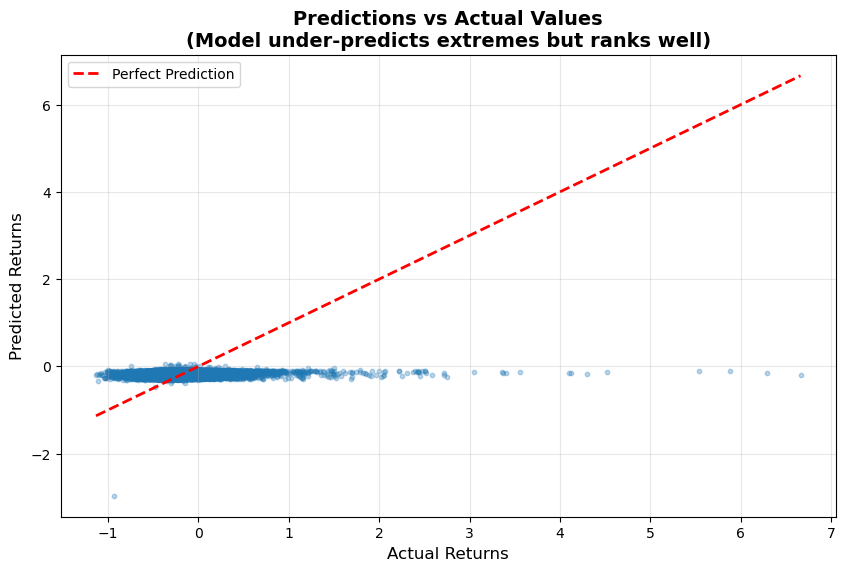

In [228]:
# Plot Predicted vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_val_actual, val_pred, alpha=0.3, s=10)
plt.plot([y_val_actual.min(), y_val_actual.max()], 
         [y_val_actual.min(), y_val_actual.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Returns', fontsize=12)
plt.ylabel('Predicted Returns', fontsize=12)
plt.title('Predictions vs Actual Values\n(Model under-predicts extremes but ranks well)', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('predictions_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

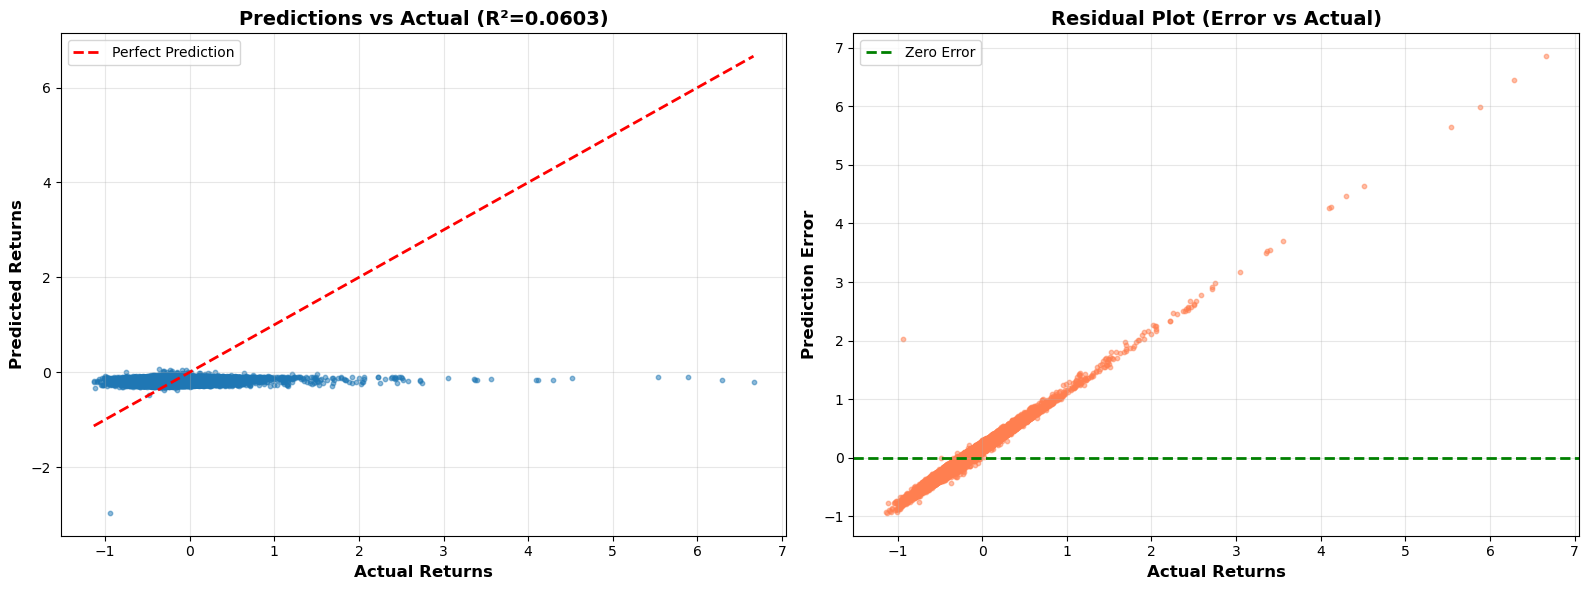

In [281]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Predictions vs Actual (with perfect prediction line)
axes[0].scatter(y_val_actual, val_pred, alpha=0.5, s=10)
axes[0].plot([y_val_actual.min(), y_val_actual.max()], 
             [y_val_actual.min(), y_val_actual.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Returns', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Returns', fontsize=12, fontweight='bold')
axes[0].set_title(f'Predictions vs Actual (R²={r2:.4f})', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# RIGHT: Residual Plot
errors = y_val_actual - val_pred
axes[1].scatter(y_val_actual, errors, alpha=0.5, s=10, color='coral')
axes[1].axhline(y=0, color='green', linestyle='--', lw=2, label='Zero Error')
axes[1].set_xlabel('Actual Returns', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Prediction Error', fontsize=12, fontweight='bold')
axes[1].set_title('Residual Plot (Error vs Actual)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Top-Left (Predictions vs Actual - Full Range):
- NNL model predicts a narrow range (~-0.2 to +0.4) while actual returns span -1 to +7
- Massive underprediction problem - the model is too conservative and fails to capture market movements
- R²=0.06 means the model explains only 6% of variance

Bottom-Right (Residual Plot):
- Errors increase linearly with actual returns - classic heteroscedasticity
- For large positive returns (>2), errors are massive (up to 7!)
- Pattern shows the model systematically misses big winners and losers


In [232]:
# Get test set predictions
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

best_model.eval()
with torch.no_grad():
    test_pred_scaled = best_model(X_test_t).numpy()

test_pred = scaler_y.inverse_transform(test_pred_scaled)
y_test_actual = y_test.reshape(-1, 1)

# Get actual next-month returns and dates for test period
test_returns = df_work.loc[test_mask, "ret_next"].values
test_dates = df_work.loc[test_mask, "date"].values
test_rf = df_work.loc[test_mask, "rf"].values if "rf" in df_work.columns else None

In [233]:
# create portfolios dataframe
df_test = pd.DataFrame({
    'date': test_dates,
    'y_actual': y_test_actual.flatten(),
    'y_pred': test_pred.flatten(),
    'ret_next': test_returns,  # Actual realized return
})


### Long-Short Portfolio Construction

**At each month $t$:**

#### Step 1: Get predictions for all stocks

For each stock $i$ in universe: $\hat{y}_{i,t} = \text{NN}(\mathbf{x}_{i,t})$

#### Step 2: Sort stocks by predicted returns

Rank stocks: $\hat{y}_{(1),t} \leq \hat{y}_{(2),t} \leq \ldots \leq \hat{y}_{(N_t),t}$

where $N_t$ = number of stocks available in month $t$

#### Step 3: Form quintiles

$$Q = \left\lfloor \frac{N_t}{4} \right\rfloor \text{ (quintile size)}$$

**Short Portfolio (Bottom 20%):**

$$\mathcal{S}_t = \{\text{stocks with ranks } 1, 2, \ldots, Q\}$$

**Long Portfolio (Top 20%):**

$$\mathcal{L}_t = \{\text{stocks with ranks } (N_t - Q + 1), \ldots, N_t\}$$

#### Step 4: Calculate portfolio returns

Equal-weighted within each quintile:

$$r_{\text{short},t} = \frac{1}{Q} \sum_{i \in \mathcal{S}_t} r_{i,t}$$

$$r_{\text{long},t} = \frac{1}{Q} \sum_{i \in \mathcal{L}_t} r_{i,t}$$

$$r_{\text{portfolio},t} = r_{\text{long},t} - r_{\text{short},t}$$

Where:
- $r_{i,t}$ = actual realized return of stock $i$ in month $t$
- $r_{\text{portfolio},t}$ = long-short portfolio return in month $t$

In [367]:
# Long-Short Portfolio function
def create_long_short_portfolio(group):
    group = group.sort_values('y_pred')
    n = len(group)
    n_quintile = max(1, n // 4)
    
    short_return = group.head(n_quintile)['ret_next'].mean()  # Bottom 25%
    long_return = group.tail(n_quintile)['ret_next'].mean()   # Top 25%
    
    return long_return - short_return

monthly_portfolio = df_test.groupby('date').apply(create_long_short_portfolio).reset_index()
monthly_portfolio.columns = ['date', 'portfolio_return']


/var/folders/7t/6w33mppn51j3pkgbzwyh6ck40000gn/T/ipykernel_52026/1743065203.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_portfolio = df_test.groupby('date').apply(create_long_short_portfolio).reset_index()


In [73]:
# Get monthly S&P 500 returns (without dividends) and Risk-Free returns
sp500_monthly = df[df['date'] >= "2020-01-01"].groupby('date')['ret_x'].first().reset_index()
sp500_monthly.columns = ['date', 'sp500_return']
rf_monthly = df[df['date'] >= "2020-01-01"].groupby('date')['rf'].first().reset_index()
rf_monthly.columns = ['date', 'rf_return']

In [369]:
# Merge all returns
returns_df = monthly_portfolio.merge(sp500_monthly, on='date', how='left')
returns_df = returns_df.merge(rf_monthly, on='date', how='left')

# Handle any missing values
returns_df = returns_df.fillna(0)

returns_df.head(5)

,date,portfolio_return,sp500_return,rf_return
0,2020-01-01,-0.002990,0.000108,0.0013
1,2020-02-01,0.048157,-0.081872,0.0012
2,2020-03-01,-0.062327,-0.121997,0.0012
3,2020-04-01,0.000452,0.128890,0.0000
4,2020-05-01,0.049388,0.047818,0.0001


In [370]:
# Calculate cumulative returns
returns_df['cum_portfolio'] = (1 + returns_df['portfolio_return']).cumprod() - 1
returns_df['cum_sp500'] = (1 + returns_df['sp500_return']).cumprod() - 1
returns_df['cum_rf'] = (1 + returns_df['rf_return']).cumprod() - 1

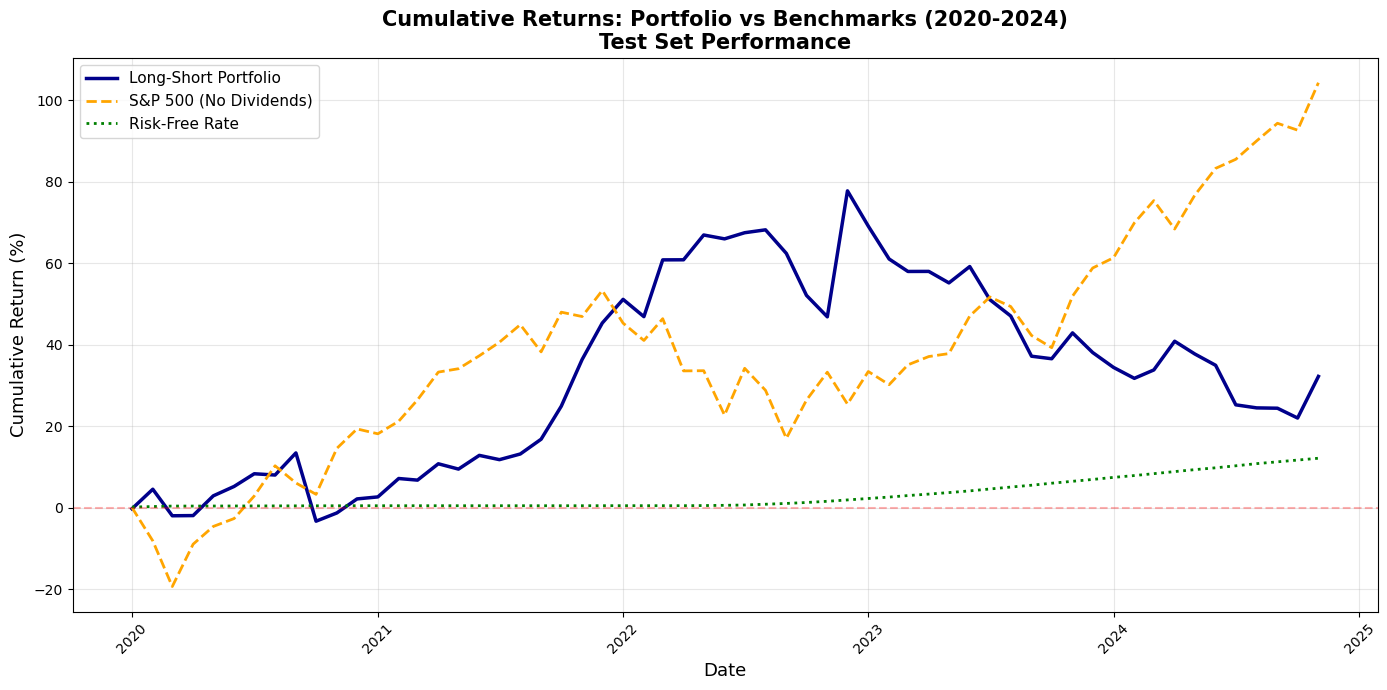

In [371]:
# Plot cumulative returns
plt.figure(figsize=(14, 7))
plt.plot(returns_df['date'], returns_df['cum_portfolio'] * 100, 
         linewidth=2.5, label='Long-Short Portfolio', color='darkblue')
plt.plot(returns_df['date'], returns_df['cum_sp500'] * 100, 
         linewidth=2, label='S&P 500 (No Dividends)', color='orange', linestyle='--')
plt.plot(returns_df['date'], returns_df['cum_rf'] * 100, 
         linewidth=2, label='Risk-Free Rate', color='green', linestyle=':')

plt.axhline(y=0, color='red', linestyle='--', alpha=0.3)
plt.xlabel('Date', fontsize=13)
plt.ylabel('Cumulative Return (%)', fontsize=13)
plt.title('Cumulative Returns: Portfolio vs Benchmarks (2020-2024)\nTest Set Performance', 
          fontsize=15, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [372]:
def calculate_metrics(returns, rf_returns):
    """Calculate comprehensive performance metrics"""
    total_return = (1 + returns).prod() - 1
    monthly_avg = returns.mean()
    monthly_vol = returns.std()
    excess_returns = returns - rf_returns
    sharpe = np.sqrt(12) * (excess_returns.mean() / excess_returns.std()) if excess_returns.std() > 0 else 0
    
    return {
        'Total Return': f"{total_return*100:.2f}%",
        'Annualized Return': f"{((1 + total_return)**(12/len(returns)) - 1)*100:.2f}%",
        'Annualized Sharpe': f"{sharpe:.4f}",
        'Monthly Avg Return': f"{monthly_avg*100:.4f}%",
        'Monthly Volatility': f"{monthly_vol*100:.4f}%"
    }

In [373]:
# Calculate for all assets
portfolio_metrics = calculate_metrics(returns_df['portfolio_return'], returns_df['rf_return'])
sp500_metrics = calculate_metrics(returns_df['sp500_return'], returns_df['rf_return'])
rf_metrics = calculate_metrics(returns_df['rf_return'], returns_df['rf_return'])


# Print comparison table
print("="*80)
print("COMPREHENSIVE PERFORMANCE COMPARISON (2020-2024)")
print("="*80)
print(f"\n{'Metric':<25} {'Portfolio':<20} {'S&P 500':<20} {'Risk-Free':<20}")
print("-"*80)
for key in portfolio_metrics.keys():
    port_val = portfolio_metrics.get(key, 'N/A')
    sp_val = sp500_metrics.get(key, 'N/A')
    rf_val = rf_metrics.get(key, 'N/A')
    print(f"{key:<25} {port_val:<20} {sp_val:<20} {rf_val:<20}")

COMPREHENSIVE PERFORMANCE COMPARISON (2020-2024)

Metric                    Portfolio            S&P 500              Risk-Free           
--------------------------------------------------------------------------------
Total Return              32.19%               104.27%              12.11%              
Annualized Return         5.84%                15.64%               2.35%               
Annualized Sharpe         0.2709               0.7627               0.0000              
Monthly Avg Return        0.6032%              1.3554%              0.1941%             
Monthly Volatility        5.1805%              5.2787%              0.1944%             


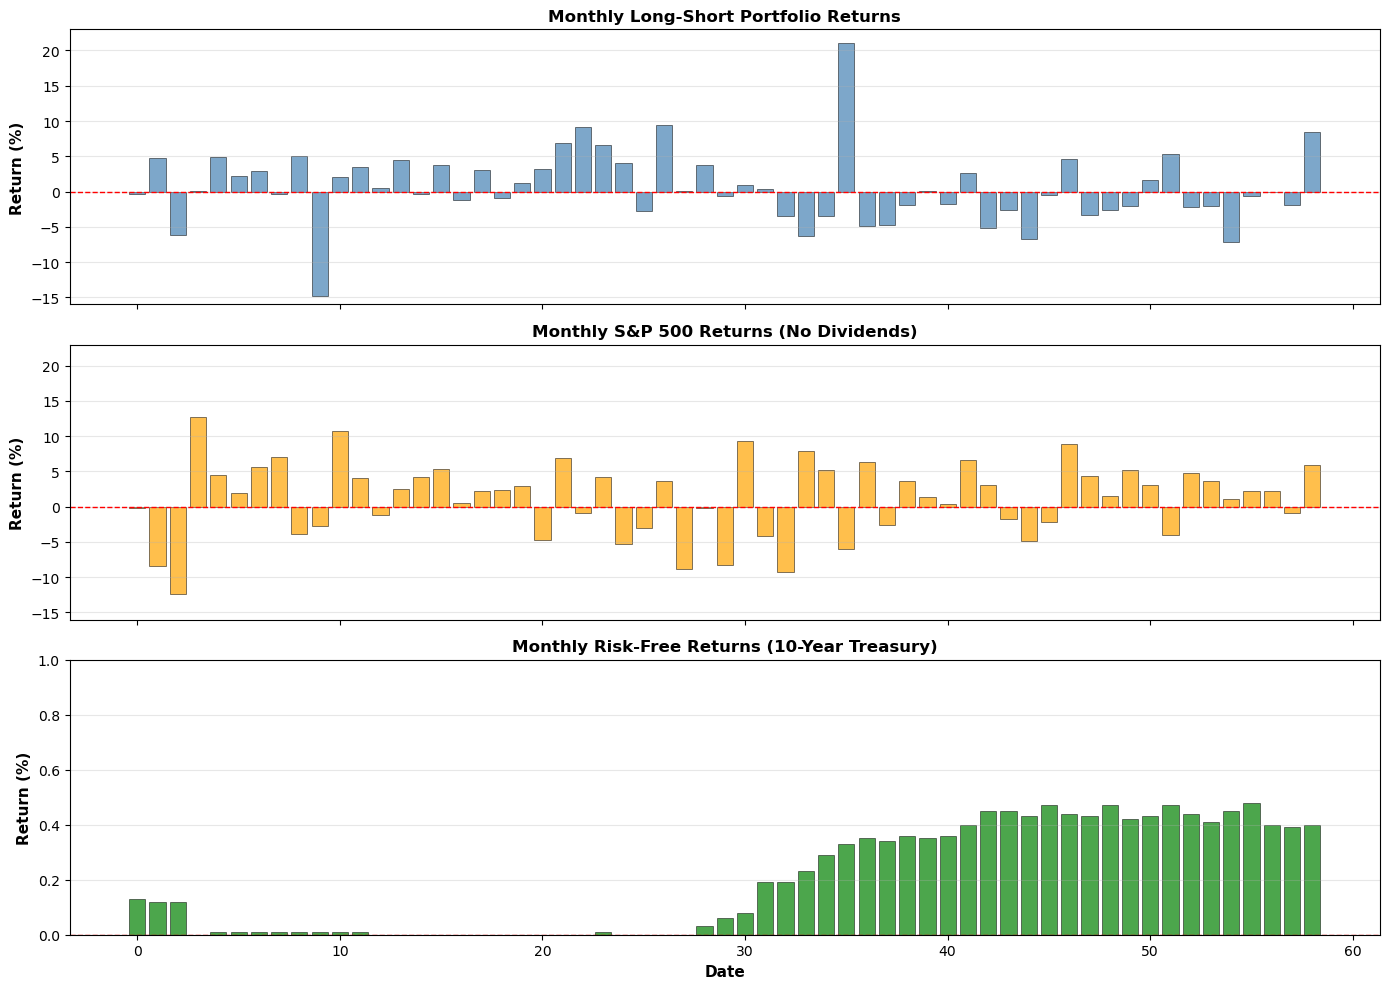

In [360]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the global y-axis range across all three series
all_returns = np.concatenate([
    returns_df['portfolio_return'].values,
    returns_df['sp500_return'].values, 
    returns_df['rf_return'].values  # Or new treasury returns
])

y_min = np.floor(all_returns.min() * 100) - 1  # Add padding
y_max = np.ceil(all_returns.max() * 100) + 1

# Create subplots with SHARED y-axis
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Portfolio Returns
axes[0].bar(returns_df.index, returns_df['portfolio_return'] * 100, 
            color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_ylabel('Return (%)', fontsize=11, fontweight='bold')
axes[0].set_title('Monthly Long-Short Portfolio Returns', fontsize=12, fontweight='bold')
axes[0].set_ylim(y_min, y_max)  # FIXED RANGE
axes[0].grid(axis='y', alpha=0.3)

# S&P 500 Returns
axes[1].bar(returns_df.index, returns_df['sp500_return'] * 100,
            color='orange', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_ylabel('Return (%)', fontsize=11, fontweight='bold')
axes[1].set_title('Monthly S&P 500 Returns (No Dividends)', fontsize=12, fontweight='bold')
axes[1].set_ylim(y_min, y_max)  # SAME RANGE
axes[1].grid(axis='y', alpha=0.3)

# Risk-Free Returns (Treasury)
axes[2].bar(returns_df.index, returns_df['rf_return'] * 100,
            color='green', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[2].set_ylabel('Return (%)', fontsize=11, fontweight='bold')
axes[2].set_title('Monthly Risk-Free Returns (10-Year Treasury)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Date', fontsize=11, fontweight='bold')
axes[2].set_ylim([0, 1])
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---

## Hybertuning

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
# Load Data
df = pd.read_parquet("5_stock_characteristics_monthly.parquet")
df.columns = [c.lower() for c in df.columns]
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["permno", "date"])

In [3]:
# Feature Engineering
df["ln_me"] = np.log(df["market_equity"].where(df["market_equity"] > 0))
df["rev1m"] = df.groupby("permno")["ret_adj"].shift(1)
df["mom12m"] = df.groupby("permno")["ret_adj"].transform(
    lambda x: (1 + x.shift(1)).rolling(11).apply(np.prod, raw=True) - 1
)
df["vol12m"] = df.groupby("permno")["ret_adj"].transform(
    lambda x: x.rolling(12).std()
)

In [4]:
# Define Target (Next Month Excess Return)
df["ret_next"] = df.groupby("permno")["ret_adj"].shift(-1)
if df["rf"].abs().mean() > 0.1: df["rf"] = df["rf"] / 100.0
df["y_next"] = df["ret_next"] - df["rf"]

In [5]:
# Select Columns
firm_features = ["ln_me", "rev1m", "mom12m", "vol12m", "turnover"]
macro_features = ["tbl", "d/p", "e/p", "b/m", "tms", "dfy", "ntis", "svar"]
feature_cols = firm_features + macro_features

In [6]:
# Keep date for later portfolio analysis
df_work = df[['date', 'permno'] + feature_cols + ["y_next", "ret_next"]].copy()
df_work = df_work.dropna()  # Drop all NaNs
df_work

,date,permno,ln_me,rev1m,mom12m,vol12m,turnover,tbl,d/p,e/p,b/m,tms,dfy,ntis,svar,y_next,ret_next
11,2000-12-01,10001,10.100513,0.062500,0.176284,0.036270,0.098479,0.0577,0.012324,0.037871,0.151852,-0.0019,0.0081,-0.002262,0.005299,0.007821,0.012821
12,2001-01-01,10001,10.113252,0.032680,0.270790,0.030880,0.083667,0.0515,0.011839,0.035490,0.150450,0.0047,0.0078,-0.003193,0.004941,-0.018058,-0.012658
13,2001-02-01,10001,10.102912,0.012821,0.267581,0.032423,0.103435,0.0488,0.012962,0.037873,0.156070,0.0061,0.0077,-0.006856,0.002528,0.034662,0.038462
14,2001-03-01,10001,10.130225,-0.012658,0.271573,0.030825,0.129932,0.0442,0.013766,0.039161,0.133114,0.0117,0.0086,-0.005213,0.007140,-0.029200,-0.025000
15,2001-04-01,10001,10.104907,0.038462,0.305185,0.033817,0.113990,0.0387,0.012707,0.034060,0.122497,0.0206,0.0087,-0.002543,0.007426,0.093536,0.097436
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1288560,2024-07-01,93436,20.424024,0.111186,-0.260067,0.137727,9.167839,0.0520,0.013120,0.035742,0.190681,-0.0095,0.0072,-0.011832,0.001748,-0.081890,-0.077390
1288561,2024-08-01,93436,20.343475,0.172781,-0.100783,0.139169,5.042310,0.0505,0.012911,0.035200,0.187377,-0.0118,0.0073,-0.011028,0.003184,0.217142,0.221942
1288562,2024-09-01,93436,20.547778,-0.077390,-0.144312,0.153502,5.002203,0.0472,0.012738,0.034754,0.183981,-0.0100,0.0074,-0.010283,0.001466,-0.049025,-0.045025
1288563,2024-10-01,93436,20.502661,0.221942,0.302679,0.140071,5.923351,0.0451,0.012949,0.035680,0.186478,-0.0041,0.0068,-0.009458,0.001062,0.377569,0.381469


In [30]:
# Splitting Data (Train < 2020, Test >= 2020)
train_mask = df_work["date"] < "2018-01-01"
val_mask = (df_work["date"] >= "2018-01-01") & (df_work["date"] < "2020-01-01")
test_mask = df_work["date"] >= "2020-01-01"

In [31]:
X_train = df_work.loc[train_mask, feature_cols].values
y_train = df_work.loc[train_mask, "y_next"].values
dates_train = df_work.loc[train_mask, "date"].values

X_val = df_work.loc[val_mask, feature_cols].values
y_val = df_work.loc[val_mask, "y_next"].values
dates_val = df_work.loc[val_mask, "date"].values

X_test = df_work.loc[test_mask, feature_cols].values
y_test = df_work.loc[test_mask, "y_next"].values
dates_test = df_work.loc[test_mask, "date"].values

In [32]:
# Scaling
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_x.fit_transform(X_train)
X_val_scaled = scaler_x.transform(X_val)
X_test_scaled = scaler_x.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()

In [33]:
# Convert to Tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val_scaled, dtype=torch.float32).view(-1, 1)

train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)


In [34]:
# MOdel Definition
class DynamicNet(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout=0.3):
        super(DynamicNet, self).__init__()
        layers = []
        in_d = input_dim
        
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_d, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))  # Added batch norm
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_d = h_dim
            
        layers.append(nn.Linear(in_d, 1))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)

In [35]:
import copy

#Training Function
def train_model(hidden_layers, lr=0.0005, epochs=200, patience=15):  # Lower LR, more time
    model = DynamicNet(X_train_scaled.shape[1], hidden_layers, dropout=0.4)  # dropout use for overfitting
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=5e-3)  # Stronger L2 regularization for overfitting
    criterion = nn.MSELoss()
    
    # Add learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                       factor=0.5, patience=5)
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = None
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_losses = []
        
        for xb, yb in train_dl:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            
            if torch.isnan(loss):
                print(f"NaN loss at epoch {epoch}")
                return model, float('nan'), history
                
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)  # Stricter clipping
            optimizer.step()
            train_losses.append(loss.item())
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
        
        avg_train_loss = np.mean(train_losses) if train_losses else float('nan')
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        
        # Update learning rate
        scheduler.step(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if best_weights is not None:
        model.load_state_dict(best_weights)
    
    return model, best_val_loss, history

In [ ]:
# Architecture Search
configs = [
    [64, 32],
    [256, 128],
    [128, 64, 32],
    [256, 128, 64],
]

best_model = None
best_config = None
lowest_loss = float('inf')
best_history = None

In [54]:
for conf in configs:
    print(f"Training architecture: {conf}")
    model, v_loss, hist = train_model(conf, lr=0.0005)
    
    if not np.isnan(v_loss) and v_loss < lowest_loss:
        lowest_loss = v_loss
        best_model = model
        best_config = conf
        best_history = hist
        print(f" -> New best! Val Loss: {lowest_loss:.6f}")
    else:
        print(f" -> Val Loss: {v_loss:.6f}")

print(f"\n{'='*60}")
print(f"Best Architecture: {best_config}")
print(f"Best Validation Loss: {lowest_loss:.6f}")
print(f"{'='*60}\n")

Training architecture: [64, 32]
Early stopping at epoch 67
 -> New best! Val Loss: 0.936540
Training architecture: [256, 128]
Early stopping at epoch 15
 -> New best! Val Loss: 0.919042
Training architecture: [128, 64, 32]
Early stopping at epoch 19
 -> Val Loss: 0.947704
Training architecture: [256, 128, 64]
Early stopping at epoch 25
 -> New best! Val Loss: 0.913283
Training architecture: [512, 256, 128, 64]
Early stopping at epoch 28
 -> Val Loss: 0.927531

Best Architecture: [256, 128, 64]
Best Validation Loss: 0.913283



In [55]:
# Get Predictions
best_model.eval()
with torch.no_grad():
    val_pred_scaled = best_model(X_val_t).numpy()

# Inverse transform
val_pred = scaler_y.inverse_transform(val_pred_scaled)
y_val_actual = y_val.reshape(-1, 1)

In [56]:
# Calculate Metrics
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error


mse = mean_squared_error(y_val_actual, val_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val_actual, val_pred)
r2 = r2_score(y_val_actual, val_pred)
ic = np.corrcoef(y_val_actual.flatten(), val_pred.flatten())[0, 1]

print("Validation Metrics:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")
print(f"Information Coefficient (IC): {ic:.4f}")

Validation Metrics:
RMSE: 0.1741
MAE: 0.1021
R²: 0.0086
Information Coefficient (IC): 0.1136


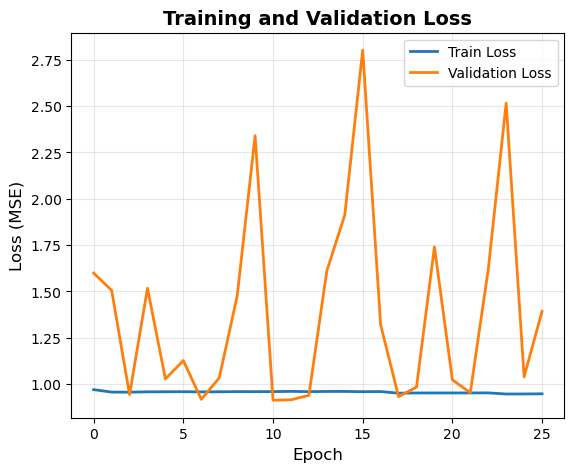

In [57]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(best_history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(best_history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

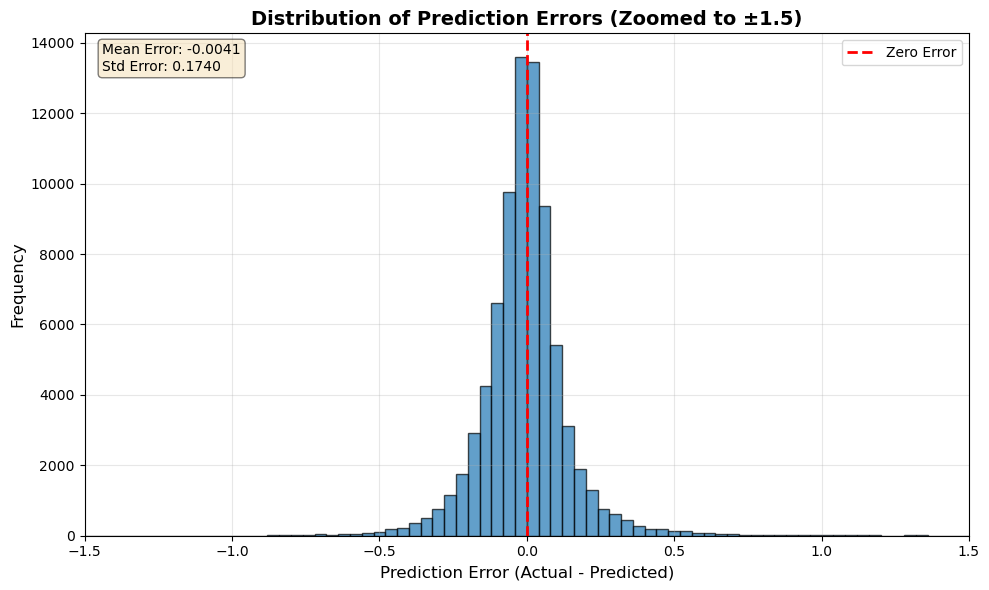


PREDICTION ERROR DISTRIBUTION ANALYSIS:
Mean Error: -0.0041
Std Error:  0.1740
Most errors fall within ±0.35 (2 standard deviations)



In [58]:
# Plot Prediction Error Distribution
residuals = y_val_actual.flatten() - val_pred.flatten()
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=100, edgecolor='black', alpha=0.7, range=(-2, 2))  # Focus on [-2, 2]
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.xlabel('Prediction Error (Actual - Predicted)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Prediction Errors (Zoomed to ±1.5)', fontsize=14, fontweight='bold')
plt.xlim(-1.5, 1.5)  # Force x-axis limit
plt.legend()
plt.grid(True, alpha=0.3)

# Add statistics text
mean_error = residuals.mean()
std_error = residuals.std()
plt.text(0.02, 0.98, f'Mean Error: {mean_error:.4f}\nStd Error: {std_error:.4f}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("PREDICTION ERROR DISTRIBUTION ANALYSIS:")
print("="*70)
print(f"Mean Error: {mean_error:.4f}")
print(f"Std Error:  {std_error:.4f}")
print(f"Most errors fall within ±{std_error*2:.2f} (2 standard deviations)")
print("="*70 + "\n")

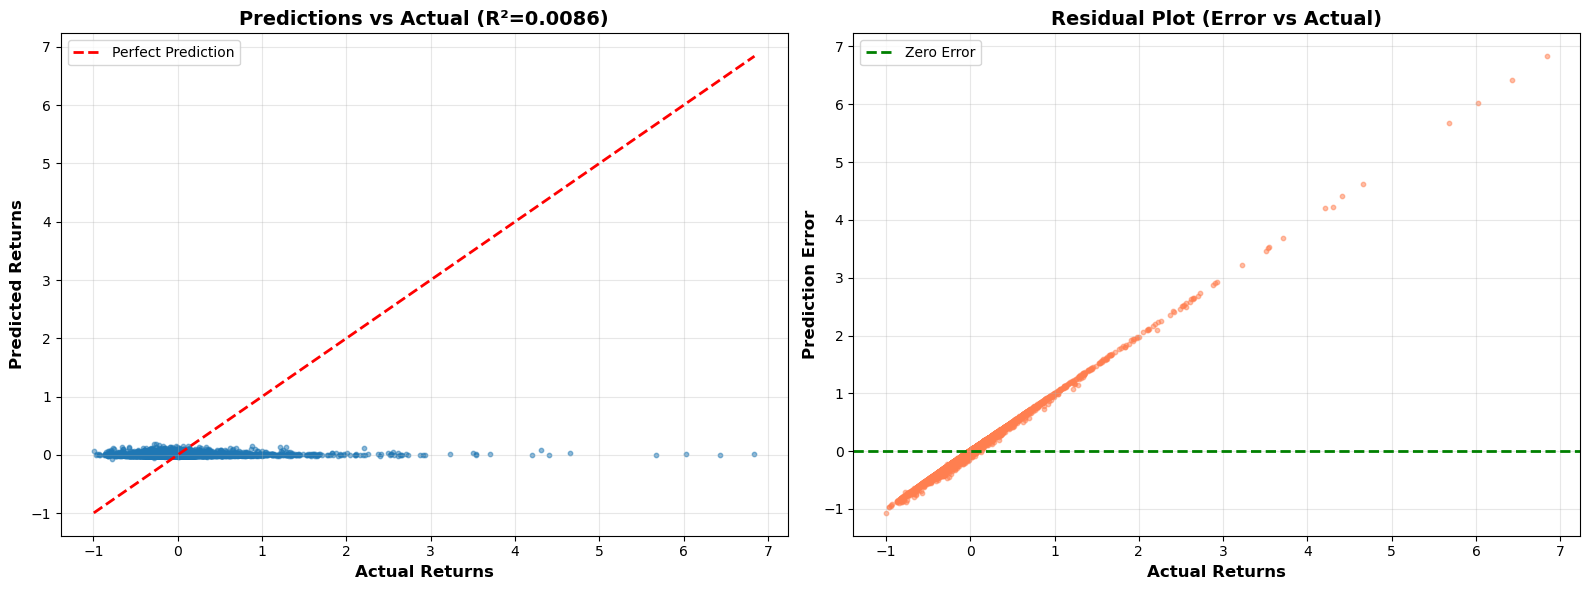

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Predictions vs Actual (with perfect prediction line)
axes[0].scatter(y_val_actual, val_pred, alpha=0.5, s=10)
axes[0].plot([y_val_actual.min(), y_val_actual.max()], 
             [y_val_actual.min(), y_val_actual.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Returns', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Returns', fontsize=12, fontweight='bold')
axes[0].set_title(f'Predictions vs Actual (R²={r2:.4f})', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# RIGHT: Residual Plot
errors = y_val_actual - val_pred
axes[1].scatter(y_val_actual, errors, alpha=0.5, s=10, color='coral')
axes[1].axhline(y=0, color='green', linestyle='--', lw=2, label='Zero Error')
axes[1].set_xlabel('Actual Returns', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Prediction Error', fontsize=12, fontweight='bold')
axes[1].set_title('Residual Plot (Error vs Actual)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [60]:
# Get test set predictions
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

best_model.eval()
with torch.no_grad():
    test_pred_scaled = best_model(X_test_t).numpy()

test_pred = scaler_y.inverse_transform(test_pred_scaled)
y_test_actual = y_test.reshape(-1, 1)

# Get actual next-month returns and dates for test period
test_returns = df_work.loc[test_mask, "ret_next"].values
test_dates = df_work.loc[test_mask, "date"].values
test_rf = df_work.loc[test_mask, "rf"].values if "rf" in df_work.columns else None

In [61]:
# create portfolios dataframe
df_test = pd.DataFrame({
    'date': test_dates,
    'y_actual': y_test_actual.flatten(),
    'y_pred': test_pred.flatten(),
    'ret_next': test_returns,  # Actual realized return
})


In [62]:
# Long-Short Portfolio function
def create_long_short_portfolio(group):
    group = group.sort_values('y_pred')
    n = len(group)
    n_quintile = max(1, n // 4)
    
    short_return = group.head(n_quintile)['ret_next'].mean()  # Bottom 25%
    long_return = group.tail(n_quintile)['ret_next'].mean()   # Top 25%
    
    return long_return - short_return

monthly_portfolio = df_test.groupby('date').apply(create_long_short_portfolio).reset_index()
monthly_portfolio.columns = ['date', 'portfolio_return']


/var/folders/7t/6w33mppn51j3pkgbzwyh6ck40000gn/T/ipykernel_17304/1743065203.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_portfolio = df_test.groupby('date').apply(create_long_short_portfolio).reset_index()


In [63]:
# Get monthly S&P 500 returns (without dividends) and Risk-Free returns
sp500_monthly = df[df['date'] >= "2020-01-01"].groupby('date')['ret_y'].first().reset_index()
sp500_monthly.columns = ['date', 'sp500_return']
rf_monthly = df[df['date'] >= "2020-01-01"].groupby('date')['rf'].first().reset_index()
rf_monthly.columns = ['date', 'rf_return']

In [64]:
# Merge all returns
returns_df = monthly_portfolio.merge(sp500_monthly, on='date', how='left')
returns_df = returns_df.merge(rf_monthly, on='date', how='left')

# Handle any missing values
returns_df = returns_df.fillna(0)

returns_df.head(5)

,date,portfolio_return,sp500_return,rf_return
0,2020-01-01,-0.028386,0.000108,0.0013
1,2020-02-01,-0.071795,-0.081872,0.0012
2,2020-03-01,0.156559,-0.121997,0.0012
3,2020-04-01,0.033021,0.128890,0.0000
4,2020-05-01,0.031270,0.047818,0.0001


In [65]:
# Calculate cumulative returns
returns_df['cum_portfolio'] = (1 + returns_df['portfolio_return']).cumprod() - 1
returns_df['cum_sp500'] = (1 + returns_df['sp500_return']).cumprod() - 1
returns_df['cum_rf'] = (1 + returns_df['rf_return']).cumprod() - 1

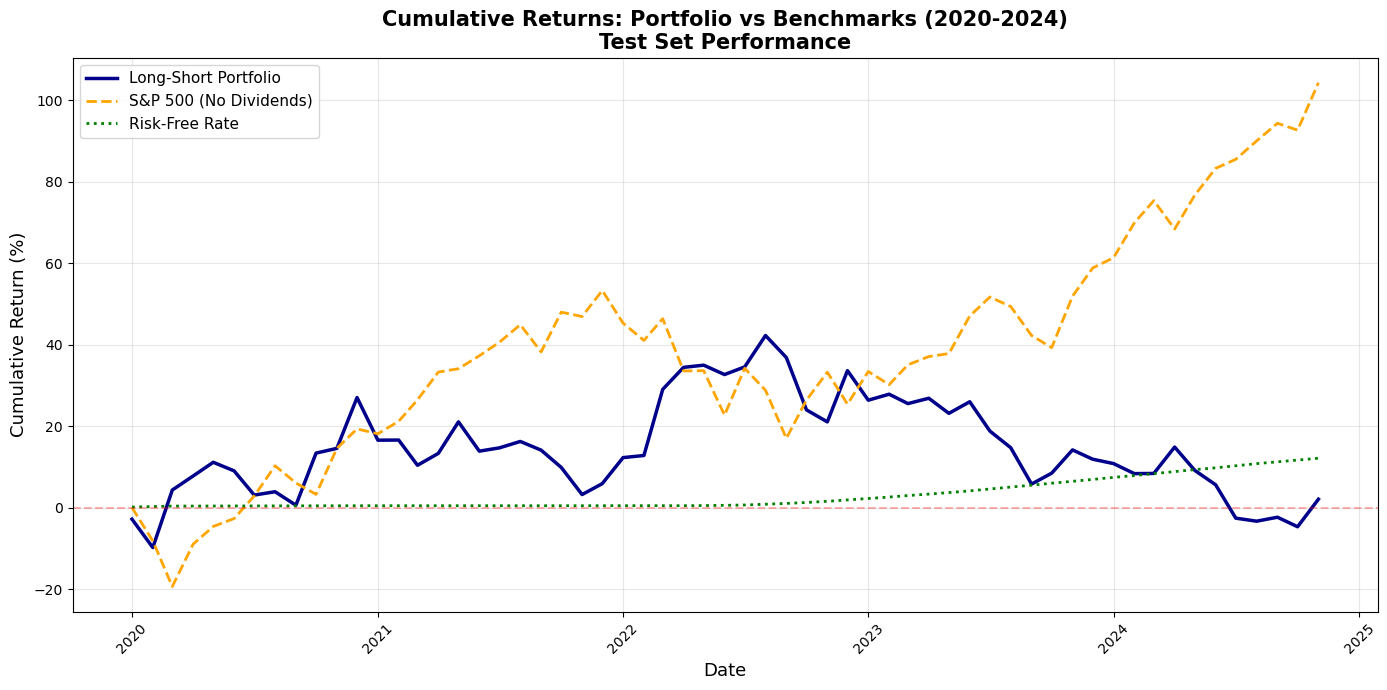

In [66]:
# Plot cumulative returns
plt.figure(figsize=(14, 7))
plt.plot(returns_df['date'], returns_df['cum_portfolio'] * 100, 
         linewidth=2.5, label='Long-Short Portfolio', color='darkblue')
plt.plot(returns_df['date'], returns_df['cum_sp500'] * 100, 
         linewidth=2, label='S&P 500 (No Dividends)', color='orange', linestyle='--')
plt.plot(returns_df['date'], returns_df['cum_rf'] * 100, 
         linewidth=2, label='Risk-Free Rate', color='green', linestyle=':')

plt.axhline(y=0, color='red', linestyle='--', alpha=0.3)
plt.xlabel('Date', fontsize=13)
plt.ylabel('Cumulative Return (%)', fontsize=13)
plt.title('Cumulative Returns: Portfolio vs Benchmarks (2020-2024)\nTest Set Performance', 
          fontsize=15, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [67]:
def calculate_metrics(returns, rf_returns):
    """Calculate comprehensive performance metrics"""
    total_return = (1 + returns).prod() - 1
    monthly_avg = returns.mean()
    monthly_vol = returns.std()
    excess_returns = returns - rf_returns
    sharpe = np.sqrt(12) * (excess_returns.mean() / excess_returns.std()) if excess_returns.std() > 0 else 0
    
    return {
        'Total Return': f"{total_return*100:.2f}%",
        'Annualized Return': f"{((1 + total_return)**(12/len(returns)) - 1)*100:.2f}%",
        'Annualized Sharpe': f"{sharpe:.4f}",
        'Monthly Avg Return': f"{monthly_avg*100:.4f}%",
        'Monthly Volatility': f"{monthly_vol*100:.4f}%"
    }

In [68]:
# Calculate for all assets
portfolio_metrics = calculate_metrics(returns_df['portfolio_return'], returns_df['rf_return'])
sp500_metrics = calculate_metrics(returns_df['sp500_return'], returns_df['rf_return'])
rf_metrics = calculate_metrics(returns_df['rf_return'], returns_df['rf_return'])


# Print comparison table
print("="*80)
print("COMPREHENSIVE PERFORMANCE COMPARISON (2020-2024)")
print("="*80)
print(f"\n{'Metric':<25} {'Portfolio':<20} {'S&P 500':<20} {'Risk-Free':<20}")
print("-"*80)
for key in portfolio_metrics.keys():
    port_val = portfolio_metrics.get(key, 'N/A')
    sp_val = sp500_metrics.get(key, 'N/A')
    rf_val = rf_metrics.get(key, 'N/A')
    print(f"{key:<25} {port_val:<20} {sp_val:<20} {rf_val:<20}")

COMPREHENSIVE PERFORMANCE COMPARISON (2020-2024)

Metric                    Portfolio            S&P 500              Risk-Free           
--------------------------------------------------------------------------------
Total Return              2.06%                104.27%              12.11%              
Annualized Return         0.41%                15.64%               2.35%               
Annualized Sharpe         -0.0068              0.7627               0.0000              
Monthly Avg Return        0.1830%              1.3554%              0.1941%             
Monthly Volatility        5.5701%              5.2787%              0.1944%             


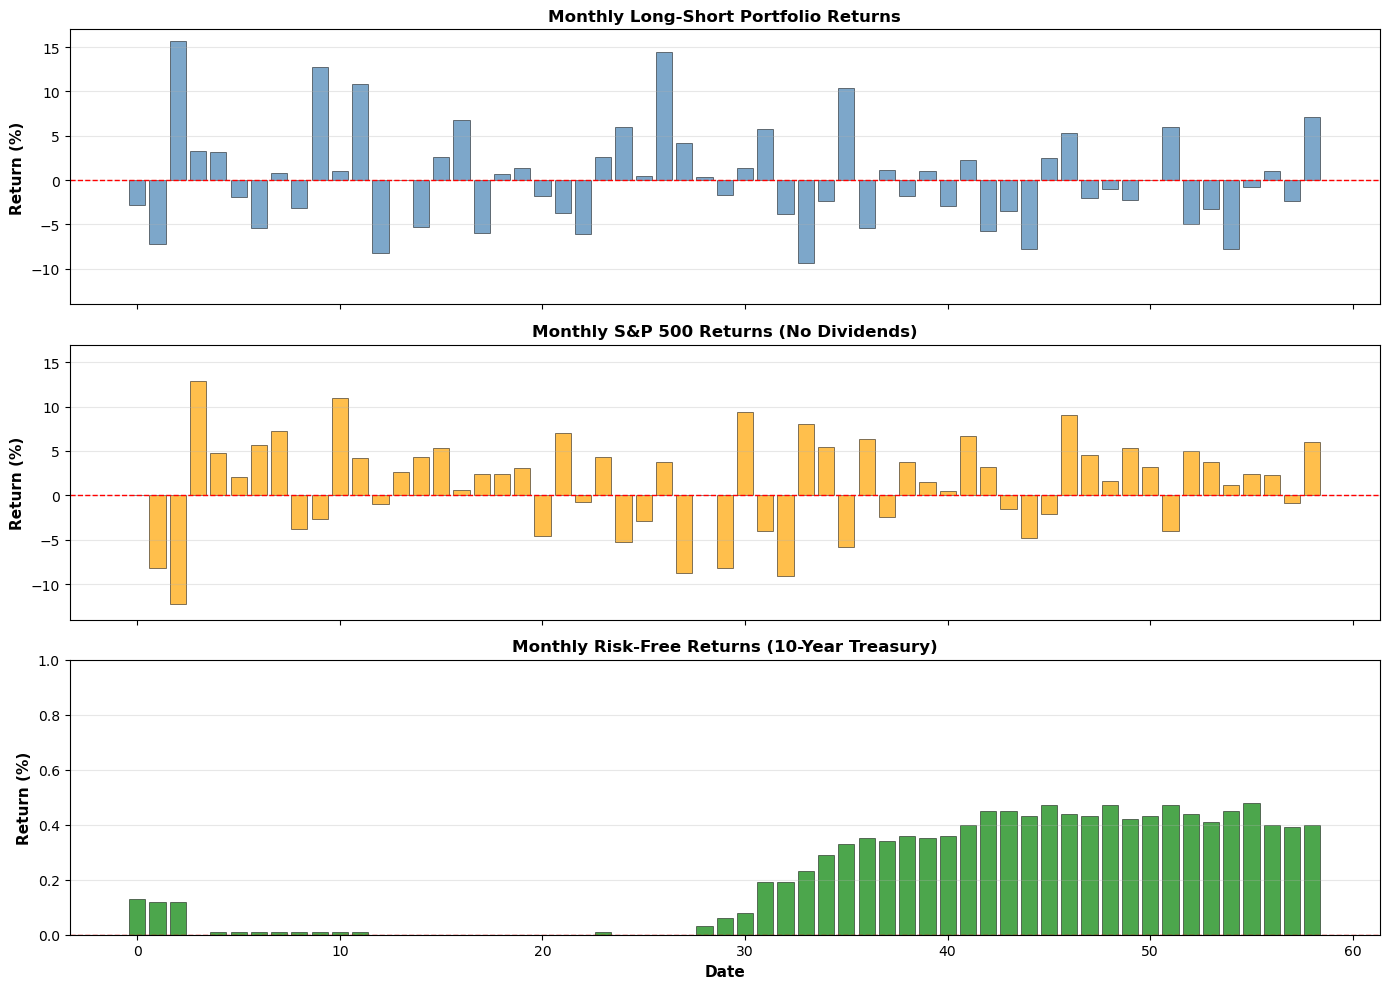

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the global y-axis range across all three series
all_returns = np.concatenate([
    returns_df['portfolio_return'].values,
    returns_df['sp500_return'].values, 
    returns_df['rf_return'].values  # Or new treasury returns
])

y_min = np.floor(all_returns.min() * 100) - 1  # Add padding
y_max = np.ceil(all_returns.max() * 100) + 1

# Create subplots with SHARED y-axis
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Portfolio Returns
axes[0].bar(returns_df.index, returns_df['portfolio_return'] * 100, 
            color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_ylabel('Return (%)', fontsize=11, fontweight='bold')
axes[0].set_title('Monthly Long-Short Portfolio Returns', fontsize=12, fontweight='bold')
axes[0].set_ylim(y_min, y_max)  # FIXED RANGE
axes[0].grid(axis='y', alpha=0.3)

# S&P 500 Returns
axes[1].bar(returns_df.index, returns_df['sp500_return'] * 100,
            color='orange', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_ylabel('Return (%)', fontsize=11, fontweight='bold')
axes[1].set_title('Monthly S&P 500 Returns (No Dividends)', fontsize=12, fontweight='bold')
axes[1].set_ylim(y_min, y_max)  # SAME RANGE
axes[1].grid(axis='y', alpha=0.3)

# Risk-Free Returns (Treasury)
axes[2].bar(returns_df.index, returns_df['rf_return'] * 100,
            color='green', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[2].set_ylabel('Return (%)', fontsize=11, fontweight='bold')
axes[2].set_title('Monthly Risk-Free Returns (10-Year Treasury)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Date', fontsize=11, fontweight='bold')
axes[2].set_ylim([0, 1])
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---


In [74]:
df['permno'].nunique()

12791

# <center> Neural Networking with shallow layers (20 factors)

In [85]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [7]:
import wrds

db = wrds.Connection(wrds_username='sunnnnnnnny')

# Check available libraries
libraries = db.list_libraries()
print("Available libraries:", libraries)

# Check if you have CRSP
if 'crsp' in libraries:
    print("✅ You have CRSP")
    tables = db.list_tables(library='crsp')
    print(f"Number of CRSP tables: {len(tables)}")
    print("First 10 tables:", tables[:10])
else:
    print("❌ No CRSP access")

# Check Compustat
if 'comp' in libraries:
    print("✅ You have Compustat")
    tables = db.list_tables(library='comp')
    print(f"Number of Compustat tables: {len(tables)}")
else:
    print("❌ No Compustat access")

# Check TAQ (for bid-ask spread)
if 'taq' in libraries:
    print("✅ You have TAQ")
else:
    print("❌ No TAQ - will need to skip bid-ask spread")

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Available libraries: ['aha_sample', 'ahasamp', 'audit', 'audit_acct_os', 'audit_audit_comp', 'audit_common', 'audit_corp_legal', 'audit_oia', 'audit_sedar', 'auditsmp', 'auditsmp_all', 'bank', 'bank_all', 'bank_premium_samp', 'banksamp', 'block', 'block_all', 'boardex', 'boardex_eur', 'boardex_na', 'boardex_row', 'boardex_trial', 'boardex_uk', 'boardsmp', 'bvd', 'bvd_amadeus_trial', 'bvd_bvdbankf_trial', 'bvd_orbis_large', 'bvd_orbis_medium', 'bvd_orbis_small', 'bvd_orbis_trial', 'bvdsamp', 'calcbench_trial', 'calcbnch', 'candid_samp', 'cboe', 'cboe_all', 'cboe_sample', 'cboesamp', 'cddsamp', 'ciq', 'ciq_common', 'ciq_keydev', 'ciq_pplintel', 'ciqsamp', 'ciqsamp_capstrct', 'ciqsamp_common', 'ciqsamp_keydev', 'ciqsamp_pplintel', 'ciqsamp_ratings', 'ciqsamp_transactions', 'ciqsamp_transcripts', 'ci

## Get Top 20 characteristics from CRSP and Compustat

### CRSP Monthly data (Stock Returns, Volume, Liquidity)


In [2]:
import wrds
import pandas as pd
from datetime import datetime

db = wrds.Connection()

crsp_query = """
SELECT 
    a.permno,
    a.date,
    a.ret,
    a.retx,
    a.vol,
    a.prc,
    a.shrout,
    a.cfacpr,
    a.cfacshr,
    b.shrcd,
    b.exchcd
FROM crsp.msf a
LEFT JOIN crsp.msenames b
    ON a.permno = b.permno 
    AND b.namedt <= a.date 
    AND a.date <= b.nameendt
WHERE a.date BETWEEN '2000-01-01' AND '2024-12-31'
    AND b.shrcd IN (10, 11)
    AND b.exchcd IN (1, 2, 3)
ORDER BY a.permno, a.date
"""

crsp_data = db.raw_sql(crsp_query)
print(f"CRSP monthly rows: {len(crsp_data):,}")

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
CRSP monthly rows: 1,294,973


### COMPUSTAT CHARACTERISTICS (Fundamentals)

In [3]:
comp_query = """
SELECT 
    gvkey,
    datadate,
    fyear,
    fyr,
    -- Balance Sheet
    at,      -- Total Assets
    lt,      -- Total Liabilities
    ceq,     -- Common Equity
    seq,     -- Stockholders Equity
    txdb,    -- Deferred Taxes
    itcb,    -- Investment Tax Credit
    pstkrv,  -- Preferred Stock Redemption Value
    pstkl,   -- Preferred Stock Liquidating Value
    pstk,    -- Preferred Stock
    che,     -- Cash and Short-Term Investments
    rect,    -- Receivables
    invt,    -- Inventories
    aco,     -- Current Assets Other
    act,     -- Current Assets Total
    lct,     -- Current Liabilities Total
    dlc,     -- Debt in Current Liabilities
    dltt,    -- Long-Term Debt
    ppent,   -- PP&E Net
    
    -- Income Statement
    sale,    -- Sales/Revenue
    revt,    -- Revenue Total
    cogs,    -- Cost of Goods Sold
    xsga,    -- SG&A Expense
    dp,      -- Depreciation
    xint,    -- Interest Expense
    ib,      -- Income Before Extraordinary Items
    ni,      -- Net Income
    oancf,   -- Operating Cash Flow
    
    -- Market data
    csho,    -- Shares Outstanding
    prcc_f   -- Price Close Annual
    
FROM comp.funda
WHERE datadate BETWEEN '1999-01-01' AND '2024-12-31'
    AND indfmt = 'INDL'
    AND datafmt = 'STD'
    AND popsrc = 'D'
    AND consol = 'C'
ORDER BY gvkey, datadate
"""

comp_data = db.raw_sql(comp_query)


### CCM LINKING (Connect CRSP and Compustat)

In [4]:
ccm_query = """
SELECT 
    gvkey,
    lpermno AS permno,
    linktype,
    linkprim,
    linkdt,
    linkenddt
FROM crsp.ccmxpf_linktable
WHERE linktype IN ('LU', 'LC')
    AND linkprim IN ('P', 'C')
"""

ccm_link = db.raw_sql(ccm_query)
print(f"CCM Link rows: {len(ccm_link):,}")

CCM Link rows: 32,849


In [5]:
print(f"CRSP rows: {len(crsp_data):,}")
print(f"Compustat rows: {len(comp_data):,}")
print(f"CCM links: {len(ccm_link):,}")

db.close()

CRSP rows: 1,294,973
Compustat rows: 300,788
CCM links: 32,849


### CALCULATE TOP 20 CHARACTERISTICS (Monthly Frequency)

In [12]:
import numpy as np
import pandas as pd

def calculate_characteristics(crsp_df, comp_df, ccm_df):
    
    # Sort data and convert dates upfront
    crsp_df = crsp_df.sort_values(['permno', 'date']).copy()
    crsp_df['date'] = pd.to_datetime(crsp_df['date'])  # ADD THIS
    comp_df = comp_df.sort_values(['gvkey', 'datadate']).copy()
    
    # --- CRSP CHARACTERISTICS ---
    
    # 1. MOMENTUM (12-month return skipping last month)
    crsp_df['ret_12_1'] = crsp_df.groupby('permno')['ret'].transform(
        lambda x: x.shift(1).rolling(11).apply(lambda y: (1 + y).prod() - 1)
    )
    
    # 2. SHORT-TERM REVERSAL (Last month return)
    crsp_df['ret_1_0'] = crsp_df.groupby('permno')['ret'].shift(1)
    
    # 3. SIZE (Log market cap)
    crsp_df['mktcap'] = abs(crsp_df['prc']) * crsp_df['shrout']
    crsp_df['log_mktcap'] = np.log(crsp_df['mktcap'])
    
    # 4. TURNOVER (Average monthly turnover)
    crsp_df['turnover'] = crsp_df['vol'] / crsp_df['shrout']
    crsp_df['turnover_3m'] = crsp_df.groupby('permno')['turnover'].transform(
        lambda x: x.rolling(3).mean()
    )
    
    # 5. VOLATILITY (12-month return volatility)
    crsp_df['vol_12m'] = crsp_df.groupby('permno')['ret'].transform(
        lambda x: x.rolling(12).std()
    )
    
    # --- MERGE CRSP WITH COMPUSTAT VIA CCM ---
    
    # Prepare CCM link
    ccm_df = ccm_df.copy()
    ccm_df['linkdt'] = pd.to_datetime(ccm_df['linkdt'])
    ccm_df['linkenddt'] = pd.to_datetime(ccm_df['linkenddt'])
    ccm_df['linkenddt'] = ccm_df['linkenddt'].fillna(pd.to_datetime('today'))
    
    # Merge
    merged = crsp_df.merge(ccm_df, on='permno', how='left')
    merged = merged[
        (merged['date'] >= merged['linkdt']) & 
        (merged['date'] <= merged['linkenddt'])
    ]
    
    # Merge with Compustat (use last fiscal year end before month)
    comp_df = comp_df.copy()
    comp_df['datadate'] = pd.to_datetime(comp_df['datadate'])
    merged['year'] = merged['date'].dt.year
    comp_df['year'] = comp_df['datadate'].dt.year
    
    merged = merged.merge(
        comp_df, 
        left_on=['gvkey', 'year'], 
        right_on=['gvkey', 'year'],
        how='left'
    )
    
    # --- COMPUSTAT CHARACTERISTICS ---
    
    # Calculate book equity (Fama-French definition)
    merged['book_equity'] = merged['seq'].fillna(
        merged['ceq'] + merged['pstk'].fillna(0)
    )
    merged['book_equity'] = merged['book_equity'].fillna(
        merged['at'] - merged['lt']
    )
    
    # 8. BOOK-TO-MARKET
    merged['bm'] = merged['book_equity'] / merged['mktcap']
    
    # 9. OPERATING PROFITABILITY (Fama-French)
    merged['op'] = (merged['revt'] - merged['cogs'].fillna(0) - 
                    merged['xsga'].fillna(0) - merged['xint'].fillna(0)) / merged['book_equity']
    
    # 10. INVESTMENT (Asset growth)
    merged['inv'] = merged.groupby('gvkey')['at'].pct_change()
    
    # 11. LEVERAGE (Total debt / Total assets)
    merged['leverage'] = (merged['dlc'].fillna(0) + merged['dltt'].fillna(0)) / merged['at']
    
    # 12. ROE (Return on equity)
    merged['roe'] = merged['ni'] / merged['book_equity']
    
    # 13. ROA (Return on assets)
    merged['roa'] = merged['ni'] / merged['at']
    
    # 14. CASH (Cash / Total assets)
    merged['cash_at'] = merged['che'] / merged['at']
    
    # 15. DIVIDEND YIELD
    merged['div_yield'] = merged.groupby('permno')['ret'].transform(
        lambda x: x.rolling(12).sum()
    ) - merged.groupby('permno')['retx'].transform(
        lambda x: x.rolling(12).sum()
    )
    
    # 16. EARNINGS-TO-PRICE
    merged['ep'] = merged['ib'] / merged['mktcap']
    
    # 17. SALES-TO-PRICE
    merged['sp'] = merged['sale'] / merged['mktcap']
    
    # 18. ACCRUALS
    merged['accruals'] = ((merged['act'].diff() - merged['che'].diff()) - 
                          (merged['lct'].diff() - merged['dlc'].diff()) - 
                          merged['dp']) / merged['at']
    
    # 19. CAPITAL EXPENDITURE
    merged['capex_at'] = merged.groupby('gvkey')['ppent'].pct_change() / merged['at']
    
    # 20. GROSS PROFITABILITY
    merged['gp'] = (merged['revt'] - merged['cogs'].fillna(0)) / merged['at']
    
    return merged

In [13]:
# Run the calculation
merged_data = calculate_characteristics(crsp_data, comp_data, ccm_link)


/var/folders/7t/6w33mppn51j3pkgbzwyh6ck40000gn/T/ipykernel_8070/822724664.py:82: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  merged['inv'] = merged.groupby('gvkey')['at'].pct_change()
/var/folders/7t/6w33mppn51j3pkgbzwyh6ck40000gn/T/ipykernel_8070/822724664.py:115: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  merged['capex_at'] = merged.groupby('gvkey')['ppent'].pct_change() / merged['at']


In [16]:
# Keep only the characteristics
char_cols = ['permno', 'date', 'ret', 'mktcap', 'ret_12_1', 'ret_1_0', 
             'log_mktcap', 'turnover_3m', 'vol_12m', 'bm', 'op', 'inv',
             'leverage', 'roe', 'roa', 'cash_at', 'div_yield', 'ep', 'sp',
             'accruals', 'capex_at', 'gp']

final_data = merged_data[char_cols].copy()

# Save as parquet instead of CSV
final_data.to_parquet('20_stock_characteristics_monthly.parquet', index=False)

## Data Preprocessing

In [40]:
import pandas as pd

# Load all datasets
chars = pd.read_parquet('20_stock_characteristics_monthly.parquet')
ff_factors = pd.read_csv('F-F_all_factors_monthly.csv')
macro = pd.read_csv('macro_index.csv')

In [41]:
print(f"chars date start: {chars['date'].min()}, end: {chars['date'].max()}")
print(f"ff_factors date start: {ff_factors['date'].min()}, end: {ff_factors['date'].max()}")
print(f"macro date start: {macro['date'].min()}, end: {macro['date'].max()}")

chars date start: 2000-01, end: 2024-12
ff_factors date start: 1963-07, end: 2025-07
macro date start: 1871-01, end: 2024-12


In [59]:
# Merge chars with ff_factors
df = chars.merge(ff_factors, on='date', how='left')
df = df.merge(macro, on='date', how='left')
df.columns = [c.lower() for c in df.columns]
df = df.sort_values(["permno", "date"])
df.head(5)

,permno,date,ret,mktcap,ret_12_1,ret_1_0,log_mktcap,turnover_3m,vol_12m,bm,...,ygap,rdsp,rsvix,gpce,gip,tchi,house,avgcor,shtint,disag
0,10001,2000-01,-0.044118,19906.25,NaN,<NA>,9.898789,NaN,NaN,0.000701,...,-3.410947,0.065980,0.052163,NaN,NaN,1.055849,NaN,0.140476,0.051651,4.333588
1,10001,2000-02,0.015385,20212.5,NaN,-0.044118,9.914057,NaN,NaN,0.000691,...,-3.370622,0.161120,0.046538,NaN,NaN,0.008782,NaN,0.152234,-0.079337,4.619126
2,10001,2000-03,-0.015758,19712.0,NaN,0.015385,9.888983,0.182842,NaN,0.000708,...,-3.442147,0.121601,0.050487,NaN,NaN,0.250551,NaN,0.183209,0.056759,4.666883
3,10001,2000-04,0.011719,19943.0,NaN,-0.015758,9.900633,0.163592,NaN,0.0007,...,-3.401997,0.083711,0.058297,NaN,NaN,0.021609,NaN,0.199117,-0.054535,4.631898
4,10001,2000-05,-0.023166,19481.0,NaN,0.011719,9.877195,0.163285,NaN,0.000717,...,-3.377789,0.061945,0.048449,NaN,NaN,-0.519085,NaN,0.217034,-0.024409,4.496980


In [65]:
# Define Target (Next Month Excess Return)
df["ret_next"] = df.groupby("permno")["ret"].shift(-1)
if df["rf"].abs().mean() > 0.1: df["rf"] = df["rf"] / 100.0
df["y_next"] = df["ret_next"] - df["rf"]
df

,permno,date,ret,mktcap,ret_12_1,ret_1_0,log_mktcap,turnover_3m,vol_12m,bm,...,rsvix,gpce,gip,tchi,house,avgcor,shtint,disag,ret_next,y_next
0,10001,2000-01,-0.044118,19906.25,NaN,<NA>,9.898789,NaN,NaN,0.000701,...,0.052163,NaN,NaN,1.055849,NaN,0.140476,0.051651,4.333588,0.015385,0.011285
1,10001,2000-02,0.015385,20212.5,NaN,-0.044118,9.914057,NaN,NaN,0.000691,...,0.046538,NaN,NaN,0.008782,NaN,0.152234,-0.079337,4.619126,-0.015758,-0.020058
2,10001,2000-03,-0.015758,19712.0,NaN,0.015385,9.888983,0.182842,NaN,0.000708,...,0.050487,NaN,NaN,0.250551,NaN,0.183209,0.056759,4.666883,0.011719,0.007019
3,10001,2000-04,0.011719,19943.0,NaN,-0.015758,9.900633,0.163592,NaN,0.0007,...,0.058297,NaN,NaN,0.021609,NaN,0.199117,-0.054535,4.631898,-0.023166,-0.027766
4,10001,2000-05,-0.023166,19481.0,NaN,0.011719,9.877195,0.163285,NaN,0.000717,...,0.048449,NaN,NaN,-0.519085,NaN,0.217034,-0.024409,4.496980,0.027668,0.022668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1279163,93436,2024-08,-0.077391,684004370.4,-0.100783,0.172781,20.343475,6.197624,0.139169,0.000107,...,NaN,NaN,NaN,1.055849,NaN,0.195877,-1.884540,2.504554,0.221942,0.217142
1279164,93436,2024-09,0.221942,839047410.0,-0.144313,-0.077391,20.547778,6.404117,0.153502,0.000087,...,NaN,NaN,NaN,1.055849,NaN,0.236572,-2.006363,2.263729,-0.045025,-0.049025
1279165,93436,2024-10,-0.045025,802033523.1006,0.302678,0.221942,20.502661,5.322621,0.140071,0.000091,...,NaN,NaN,NaN,1.055849,NaN,0.256120,-2.057976,2.846782,0.381469,0.377569
1279166,93436,2024-11,0.381469,1107984309.6,0.040695,-0.045025,20.825808,5.803941,0.167882,0.000066,...,NaN,NaN,NaN,1.055849,NaN,0.176644,-2.078823,3.231256,0.170008,0.166008


In [72]:
# Define the features you want to keep
firm_features = ['ret', 'mktcap', 'ret_12_1', 'ret_1_0', 
                 'log_mktcap', 'turnover_3m', 'vol_12m', 'bm', 'op', 'inv',
                 'leverage', 'roe', 'roa', 'cash_at', 'div_yield', 'ep', 'sp',
                 'accruals', 'capex_at', 'gp']

macro_features = ["tbl", "d/p", "e/p", "b/m", "tms", "dfy", "ntis", "svar"]
feature_cols = firm_features + macro_features

In [73]:
# Keep date for later portfolio analysis
df_work = df[['date', 'permno'] + feature_cols + ["y_next", "ret_next"]].copy()
df_work = df_work.dropna()  # Drop all NaNs
df_work

,date,permno,ret,mktcap,ret_12_1,ret_1_0,log_mktcap,turnover_3m,vol_12m,bm,...,tbl,d/p,e/p,b/m,tms,dfy,ntis,svar,y_next,ret_next
11,2000-12,10001,0.03268,24355.5,0.176284,0.0625,10.100513,0.171715,0.036270,0.000573,...,0.0577,0.012324,0.037871,0.151852,-0.0019,0.0081,-0.002262,0.005299,0.007821,0.012821
12,2001-01,10001,0.012821,24667.75,0.270790,0.03268,10.113252,0.122548,0.030880,0.000633,...,0.0515,0.011839,0.035490,0.150450,0.0047,0.0078,-0.003193,0.004941,-0.018058,-0.012658
13,2001-02,10001,-0.012658,24414.0,0.267581,0.012821,10.102912,0.095193,0.032423,0.00064,...,0.0488,0.012962,0.037873,0.156070,0.0061,0.0077,-0.006856,0.002528,0.034662,0.038462
14,2001-03,10001,0.038462,25090.0,0.271573,-0.012658,10.130225,0.105678,0.030825,0.000622,...,0.0442,0.013766,0.039161,0.133114,0.0117,0.0086,-0.005213,0.007140,-0.0292,-0.025
15,2001-04,10001,-0.025,24462.75,0.305185,0.038462,10.104907,0.115785,0.033817,0.000638,...,0.0387,0.012707,0.034060,0.122497,0.0206,0.0087,-0.002543,0.007426,0.093536,0.097436
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1279162,2024-07,93436,0.172781,741380136.7464,-0.260067,0.111186,20.424024,6.253263,0.137727,0.000098,...,0.0520,0.013120,0.035742,0.190681,-0.0095,0.0072,-0.011832,0.001748,-0.081891,-0.077391
1279163,2024-08,93436,-0.077391,684004370.4,-0.100783,0.172781,20.343475,6.197624,0.139169,0.000107,...,0.0505,0.012911,0.035200,0.187377,-0.0118,0.0073,-0.011028,0.003184,0.217142,0.221942
1279164,2024-09,93436,0.221942,839047410.0,-0.144313,-0.077391,20.547778,6.404117,0.153502,0.000087,...,0.0472,0.012738,0.034754,0.183981,-0.0100,0.0074,-0.010283,0.001466,-0.049025,-0.045025
1279165,2024-10,93436,-0.045025,802033523.1006,0.302678,0.221942,20.502661,5.322621,0.140071,0.000091,...,0.0451,0.012949,0.035680,0.186478,-0.0041,0.0068,-0.009458,0.001062,0.377569,0.381469


In [74]:
# Splitting Data (Train < 2020, Test >= 2020)
train_mask = df_work["date"] < "2020-01-01"
val_mask = (df_work["date"] >= "2020-01-01") & (df_work["date"] < "2022-01-01")
test_mask = df_work["date"] >= "2022-01-01"

In [164]:
X_train = df_work.loc[train_mask, feature_cols].values
y_train = df_work.loc[train_mask, "y_next"].values
dates_train = df_work.loc[train_mask, "date"].values

X_val = df_work.loc[val_mask, feature_cols].values
y_val = df_work.loc[val_mask, "y_next"].values
dates_val = df_work.loc[val_mask, "date"].values

X_test = df_work.loc[test_mask, feature_cols].values
y_test = df_work.loc[test_mask, "y_next"].values
dates_test = df_work.loc[test_mask, "date"].values

In [165]:
print("Checking for problematic values...")
X_train_np = np.asarray(X_train, dtype=np.float64)
X_val_np = np.asarray(X_val, dtype=np.float64)
X_test_np = np.asarray(X_test, dtype=np.float64)

print(f"X_train - NaN: {np.isnan(X_train_np).sum()}, Inf: {np.isinf(X_train_np).sum()}")
print(f"X_val - NaN: {np.isnan(X_val_np).sum()}, Inf: {np.isinf(X_val_np).sum()}")
print(f"X_test - NaN: {np.isnan(X_test_np).sum()}, Inf: {np.isinf(X_test_np).sum()}")


Checking for problematic values...
X_train - NaN: 2848, Inf: 139
X_val - NaN: 667, Inf: 19
X_test - NaN: 2000, Inf: 24


In [166]:
# Replace inf with NaN
X_train_clean = np.where(np.isinf(X_train_np), np.nan, X_train_np)
X_val_clean = np.where(np.isinf(X_val_np), np.nan, X_val_np)
X_test_clean = np.where(np.isinf(X_test_np), np.nan, X_test_np)


In [171]:
# Impute NaN with median from training set
from scipy.stats import mstats

def winsorize_returns(y, limits=(0.01, 0.01)):
    """Cap extreme values at 1st and 99th percentile"""
    # Convert to numpy array if it's a pandas Series
    if hasattr(y, 'values'):
        y_array = y.values
    else:
        y_array = y
    
    # Convert to standard numpy float64 (not nullable)
    y_array = np.asarray(y_array, dtype=np.float64)
    
    return mstats.winsorize(y_array, limits=limits)

In [172]:
# Apply winsorization
y_train_clean = winsorize_returns(y_train)
y_val_clean = winsorize_returns(y_val)
y_test_clean = winsorize_returns(y_test)

In [173]:
print(f"\nTarget outlier handling:")
print(f"Train - Before: min={y_train.min():.4f}, max={y_train.max():.4f}")
print(f"Train - After:  min={y_train_clean.min():.4f}, max={y_train_clean.max():.4f}")
print(f"Val - Before: min={y_val.min():.4f}, max={y_val.max():.4f}")
print(f"Val - After:  min={y_val_clean.min():.4f}, max={y_val_clean.max():.4f}")



Target outlier handling:
Train - Before: min=-0.9722, max=15.9845
Train - After:  min=-0.4100, max=0.5950
Val - Before: min=-0.8994, max=17.6045
Val - After:  min=-0.4419, max=0.7715


In [175]:
# Use RobustScaler instead of StandardScaler for features
from sklearn.preprocessing import RobustScaler, StandardScaler

# RobustScaler uses median/IQR, resistant to outliers
scaler_x = RobustScaler()
scaler_y = StandardScaler()  # Keep standard for target (already winsorized)

X_train_scaled = scaler_x.fit_transform(X_train_clean)
X_val_scaled = scaler_x.transform(X_val_clean)  # Use train stats
X_test_scaled = scaler_x.transform(X_test_clean)  # Use train stats

y_train_scaled = scaler_y.fit_transform(y_train_clean.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val_clean.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test_clean.reshape(-1, 1)).flatten()

In [178]:
# After imputation, BEFORE scaling
from sklearn.preprocessing import RobustScaler

def winsorize_features(X, limits=(0.02, 0.98), fit_on=None):
    """
    Winsorize features at 2nd and 98th percentile.
    If fit_on is provided, use its percentiles for all sets.
    """
    X_winsorized = X.copy()
    
    if fit_on is not None:
        # Use training set percentiles for all sets
        for i in range(X.shape[1]):
            lower = np.percentile(fit_on[:, i], limits[0] * 100)
            upper = np.percentile(fit_on[:, i], limits[1] * 100)
            X_winsorized[:, i] = np.clip(X[:, i], lower, upper)
    else:
        # Compute percentiles from this set
        for i in range(X.shape[1]):
            lower = np.percentile(X[:, i], limits[0] * 100)
            upper = np.percentile(X[:, i], limits[1] * 100)
            X_winsorized[:, i] = np.clip(X[:, i], lower, upper)
    
    return X_winsorized

In [179]:
# Apply winsorization using TRAINING PERCENTILES for all sets
print("Winsorizing features at 2nd/98th percentile...")
X_train_winsorized = winsorize_features(X_train_clean, limits=(0.02, 0.98))
X_val_winsorized = winsorize_features(X_val_clean, limits=(0.02, 0.98), fit_on=X_train_clean)
X_test_winsorized = winsorize_features(X_test_clean, limits=(0.02, 0.98), fit_on=X_train_clean)


Winsorizing features at 2nd/98th percentile...


In [198]:
# Now scale with RobustScaler
scaler_x = RobustScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_x.fit_transform(X_train_winsorized)
X_val_scaled = scaler_x.transform(X_val_winsorized)
X_test_scaled = scaler_x.transform(X_test_winsorized)

y_train_scaled = scaler_y.fit_transform(y_train_clean.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val_clean.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test_clean.reshape(-1, 1)).flatten()


In [199]:
print("Target distribution AFTER scaling:")
print(f"Train - Mean: {y_train_scaled.mean():.4f}, Std: {y_train_scaled.std():.4f}")
print(f"Val   - Mean: {y_val_scaled.mean():.4f}, Std: {y_val_scaled.std():.4f}")


Target distribution AFTER scaling:
Train - Mean: -0.0000, Std: 1.0000
Val   - Mean: 0.0820, Std: 1.1997


In [181]:
# Re-verify
print(f"\n{'='*60}")
print("VERIFICATION AFTER FEATURE WINSORIZATION")
print(f"{'='*60}")

bad_features = []
for i in range(X_train_scaled.shape[1]):
    train_std = X_train_scaled[:, i].std()
    val_std = X_val_scaled[:, i].std()
    ratio = val_std / train_std if train_std > 1e-6 else 0
    
    if ratio > 2.0 or ratio < 0.5:
        print(f"Feature {i} ({feature_cols[i]}): Ratio={ratio:.4f}")
        if ratio > 3.0 or ratio < 0.3:
            bad_features.append(i)
            print(f"  ⚠️ STILL PROBLEMATIC - consider removing")

if len(bad_features) > 0:
    print(f"\n{len(bad_features)} features still problematic after winsorization")
    print(f"Consider removing: {[feature_cols[i] for i in bad_features]}")
else:
    print("\n✓ All features now have reasonable distributions!")



VERIFICATION AFTER FEATURE WINSORIZATION
Feature 20 (tbl): Ratio=0.1827
  ⚠️ STILL PROBLEMATIC - consider removing
Feature 22 (e/p): Ratio=0.4318
Feature 24 (tms): Ratio=0.3453

1 features still problematic after winsorization
Consider removing: ['tbl']


In [182]:
# Just use all features - the model will learn to handle it
good_features = list(range(len(feature_cols)))  # Keep all 28 features

X_train_scaled = X_train_scaled[:, good_features]
X_val_scaled = X_val_scaled[:, good_features]
X_test_scaled = X_test_scaled[:, good_features]

In [200]:
# Convert to tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).reshape(-1, 1)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val_scaled, dtype=torch.float32).reshape(-1, 1)

train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)

In [184]:
# MOdel Definition
class DynamicNet(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout=0.3):
        super(DynamicNet, self).__init__()
        layers = []
        in_d = input_dim
        
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_d, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))  # Added batch norm
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_d = h_dim
            
        layers.append(nn.Linear(in_d, 1))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)

In [185]:
# 1. Check data distributions
print("="*60)
print("DATA DISTRIBUTION CHECK")
print("="*60)

print("\nTarget variable (returns) distribution:")
print(f"Train - Mean: {y_train.mean():.4f}, Std: {y_train.std():.4f}, Min: {y_train.min():.4f}, Max: {y_train.max():.4f}")
print(f"Val   - Mean: {y_val.mean():.4f}, Std: {y_val.std():.4f}, Min: {y_val.min():.4f}, Max: {y_val.max():.4f}")

print("\nFeature distributions (first 3 features after scaling):")
for i in range(min(3, X_train_scaled.shape[1])):
    print(f"Feature {i}:")
    print(f"  Train - Mean: {X_train_scaled[:, i].mean():.4f}, Std: {X_train_scaled[:, i].std():.4f}")
    print(f"  Val   - Mean: {X_val_scaled[:, i].mean():.4f}, Std: {X_val_scaled[:, i].std():.4f}")


DATA DISTRIBUTION CHECK

Target variable (returns) distribution:
Train - Mean: 0.0101, Std: 0.1892, Min: -0.9722, Max: 15.9845
Val   - Mean: 0.0256, Std: 0.2624, Min: -0.8994, Max: 17.6045

Feature distributions (first 3 features after scaling):
Feature 0:
  Train - Mean: 0.0274, Std: 0.9824
  Val   - Mean: 0.0607, Std: 1.1059
Feature 1:
  Train - Mean: 1.4568, Std: 4.1943
  Val   - Mean: 3.0761, Std: 6.1715
Feature 2:
  Train - Mean: 0.0962, Std: 0.9425
  Val   - Mean: 0.3958, Std: 1.1864


In [187]:
# 3. Look at actual predictions
print("\nPrediction statistics:")
print(f"Mean prediction: {val_pred.mean():.4f}")
print(f"Std prediction: {val_pred.std():.4f}")
print(f"Min prediction: {val_pred.min():.4f}")
print(f"Max prediction: {val_pred.max():.4f}")
print(f"Unique values: {len(np.unique(np.round(val_pred, 4)))}")



Prediction statistics:
Mean prediction: -0.1342
Std prediction: 0.1732
Min prediction: -3.6049
Max prediction: 2.8188
Unique values: 8613


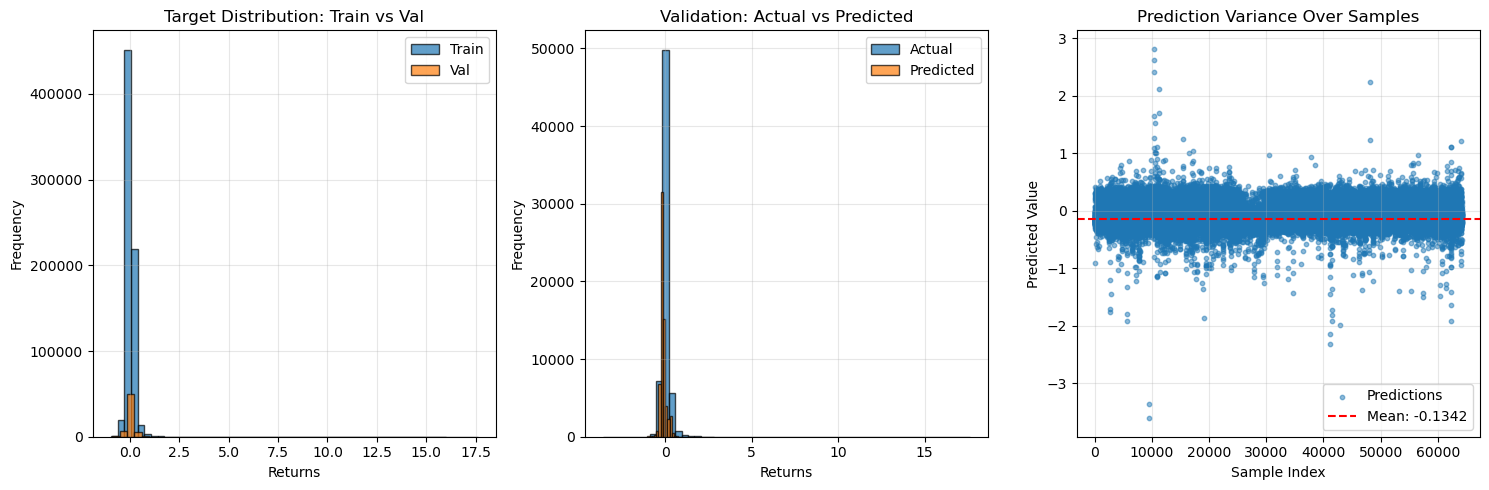

In [188]:
# 4. Histogram comparison
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(np.asarray(y_train), bins=50, alpha=0.7, label='Train', edgecolor='black')
plt.hist(np.asarray(y_val), bins=50, alpha=0.7, label='Val', edgecolor='black')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.title('Target Distribution: Train vs Val')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist(np.asarray(y_val), bins=50, alpha=0.7, label='Actual', edgecolor='black')
plt.hist(val_pred, bins=50, alpha=0.7, label='Predicted', edgecolor='black')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.title('Validation: Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(range(len(val_pred)), val_pred, alpha=0.5, s=10, label='Predictions')
plt.axhline(y=val_pred.mean(), color='r', linestyle='--', label=f'Mean: {val_pred.mean():.4f}')
plt.xlabel('Sample Index')
plt.ylabel('Predicted Value')
plt.title('Prediction Variance Over Samples')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [201]:
import copy

#Training Function
def train_model(hidden_layers, lr=0.001, epochs=100, patience=10):
    model = DynamicNet(X_train_scaled.shape[1], hidden_layers, dropout=0.2)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()
    
    # NO scheduler - keep it simple
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = None
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        
        for xb, yb in train_dl:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            
            if torch.isnan(loss):
                print(f"NaN loss at epoch {epoch}")
                return model, float('nan'), history, epoch
                
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())
        
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
        
        avg_train_loss = np.mean(train_losses)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            break
    
    if best_weights is not None:
        model.load_state_dict(best_weights)
    
    return model, best_val_loss, history, epoch + 1

In [202]:
# Architecture Search
configs = [
    [128],
    [128, 64],
    [256, 128, 64]
]

best_model_20_char = None
best_config_20_char = None
lowest_loss_20_char = float('inf')
best_history_20_char = None

In [203]:
for conf in configs:
    print(f"Training architecture: {conf}")
    model, v_loss, hist, epochs_run = train_model(conf, lr=0.0001, epochs=100, patience=15)
    
    print(f"Early stopping at epoch {epochs_run - 1}")
    
    if not np.isnan(v_loss) and v_loss < lowest_loss_20_char:
        lowest_loss_20_char = v_loss
        best_model_20_char = model
        best_config_20_char = conf
        best_history_20_char = hist
        print(f" -> New best! Val Loss: {lowest_loss_20_char:.6f}")
    else:
        print(f" -> Val Loss: {v_loss:.6f}")

print(f"\n{'='*60}")
print(f"Best Architecture: {best_config_20_char}")
print(f"Best Validation Loss: {lowest_loss_20_char:.6f}")
print(f"{'='*60}\n")

Training architecture: [128]
Early stopping at epoch 15
 -> New best! Val Loss: 1.477390
Training architecture: [128, 64]
Early stopping at epoch 15
 -> Val Loss: 1.492090
Training architecture: [256, 128, 64]
Early stopping at epoch 15
 -> Val Loss: 1.545334

Best Architecture: [128]
Best Validation Loss: 1.477390




DIAGNOSTIC ANALYSIS
Prediction variance ratio: 0.5236
  → Should be > 0.3, yours is 0.5236
Correlation: 0.0144
  → Negative means model learned INVERSE relationship!


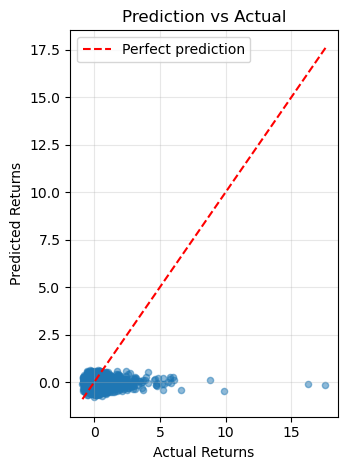

In [204]:
# After getting predictions, add this analysis:
print("\n" + "="*60)
print("DIAGNOSTIC ANALYSIS")
print("="*60)

# Check if model is just predicting near-constant
pred_variance_ratio = val_pred.std() / y_val_actual.std()
print(f"Prediction variance ratio: {pred_variance_ratio:.4f}")
print(f"  → Should be > 0.3, yours is {pred_variance_ratio:.4f}")

# Check correlation direction
correlation = np.corrcoef(y_val_actual.flatten(), val_pred.flatten())[0, 1]
print(f"Correlation: {correlation:.4f}")
print(f"  → Negative means model learned INVERSE relationship!")

# Plot prediction vs actual
plt.subplot(1, 2, 2)
plt.scatter(y_val_actual, val_pred, alpha=0.5, s=20)
plt.plot([y_val_actual.min(), y_val_actual.max()], 
         [y_val_actual.min(), y_val_actual.max()], 
         'r--', label='Perfect prediction')
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.title('Prediction vs Actual')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [205]:
# Get Predictions
best_model_20_char.eval()
with torch.no_grad():
    val_pred = best_model_20_char(X_val_t).numpy()

# Inverse transform to original scale
val_pred_original = scaler_y.inverse_transform(val_pred_scaled)
val_actual_original = scaler_y.inverse_transform(y_val_t.numpy())

# Now calculate metrics
from scipy.stats import pearsonr
corr, _ = pearsonr(val_actual_original.flatten(), val_pred_original.flatten())
print(f"Correlation: {corr:.4f}")

Correlation: 0.1924


In [206]:
# Calculate Metrics
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

# Ensure y_val_actual is a proper numpy array
y_val_actual = np.asarray(y_val_actual, dtype=np.float64)
val_pred = np.asarray(val_pred, dtype=np.float64).flatten()

mse = mean_squared_error(y_val_actual, val_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val_actual, val_pred)
r2 = r2_score(y_val_actual, val_pred)
ic = np.corrcoef(y_val_actual.flatten(), val_pred.flatten())[0, 1]

print("Validation Metrics:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")
print(f"Information Coefficient (IC): {ic:.4f}")

Validation Metrics:
RMSE: 0.3086
MAE: 0.1812
R²: -0.3832
Information Coefficient (IC): -0.0070


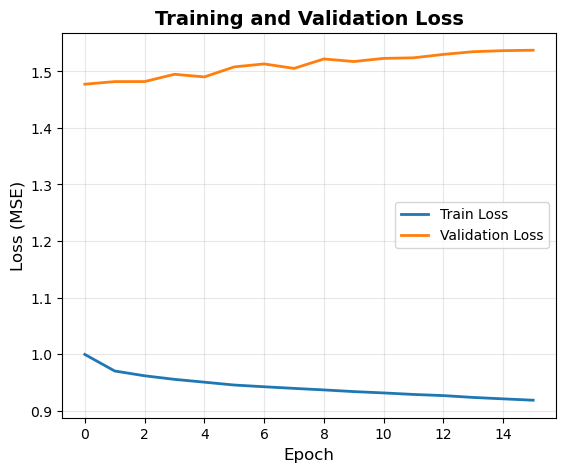

In [207]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(best_history_20_char['train_loss'], label='Train Loss', linewidth=2)
plt.plot(best_history_20_char['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

In [208]:
# 1. DIAGNOSE: Check if you're just predicting the mean
print("Validation Set Statistics:")
print(f"Actual returns - Mean: {y_val_actual.mean():.6f}, Std: {y_val_actual.std():.6f}")
print(f"Predicted returns - Mean: {val_pred.mean():.6f}, Std: {val_pred.std():.6f}")
print(f"Prediction range: [{val_pred.min():.6f}, {val_pred.max():.6f}]")

Validation Set Statistics:
Actual returns - Mean: 0.025595, Std: 0.262388
Predicted returns - Mean: -0.047753, Std: 0.143111
Prediction range: [-0.878434, 0.651257]


In [209]:
# 2. FEATURE IMPORTANCE: Check which features have any signal
import pandas as pd
from scipy.stats import spearmanr

feature_correlations = []
for i in range(X_train_scaled.shape[1]):
    corr, _ = spearmanr(X_train_scaled[:, i], y_train)
    feature_correlations.append(abs(corr))

print(f"\nTop 10 features by correlation with target:")
top_features = np.argsort(feature_correlations)[-10:][::-1]
for idx in top_features:
    print(f"Feature {idx}: {feature_correlations[idx]:.4f}")


Top 10 features by correlation with target:
Feature 15: 0.1141
Feature 12: 0.0991
Feature 11: 0.0720
Feature 8: 0.0674
Feature 7: 0.0585
Feature 23: 0.0539
Feature 6: 0.0506
Feature 16: 0.0445
Feature 4: 0.0434
Feature 1: 0.0434


In [ ]:
# Plot Prediction Error Distribution
residuals = y_val_actual.flatten() - val_pred.flatten()
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=100, edgecolor='black', alpha=0.7, range=(-2, 2))  # Focus on [-2, 2]
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.xlabel('Prediction Error (Actual - Predicted)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Prediction Errors (Zoomed to ±1.5)', fontsize=14, fontweight='bold')
plt.xlim(-1.5, 1.5)  # Force x-axis limit
plt.legend()
plt.grid(True, alpha=0.3)

# Add statistics text
mean_error = residuals.mean()
std_error = residuals.std()
plt.text(0.02, 0.98, f'Mean Error: {mean_error:.4f}\nStd Error: {std_error:.4f}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("PREDICTION ERROR DISTRIBUTION ANALYSIS:")
print("="*70)
print(f"Mean Error: {mean_error:.4f}")
print(f"Std Error:  {std_error:.4f}")
print(f"Most errors fall within ±{std_error*2:.2f} (2 standard deviations)")
print("="*70 + "\n")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Predictions vs Actual (with perfect prediction line)
axes[0].scatter(y_val_actual, val_pred, alpha=0.5, s=10)
axes[0].plot([y_val_actual.min(), y_val_actual.max()], 
             [y_val_actual.min(), y_val_actual.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Returns', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Returns', fontsize=12, fontweight='bold')
axes[0].set_title(f'Predictions vs Actual (R²={r2:.4f})', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# RIGHT: Residual Plot
errors = y_val_actual - val_pred
axes[1].scatter(y_val_actual, errors, alpha=0.5, s=10, color='coral')
axes[1].axhline(y=0, color='green', linestyle='--', lw=2, label='Zero Error')
axes[1].set_xlabel('Actual Returns', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Prediction Error', fontsize=12, fontweight='bold')
axes[1].set_title('Residual Plot (Error vs Actual)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Get test set predictions
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

best_model_20_char.eval()
with torch.no_grad():
    test_pred_scaled = best_model(X_test_t).numpy()

test_pred = scaler_y.inverse_transform(test_pred_scaled)
y_test_actual = y_test.reshape(-1, 1)

# Get actual next-month returns and dates for test period
test_returns = df_work.loc[test_mask, "ret_next"].values
test_dates = df_work.loc[test_mask, "date"].values
test_rf = df_work.loc[test_mask, "rf"].values if "rf" in df_work.columns else None

In [ ]:
# create portfolios dataframe
df_test = pd.DataFrame({
    'date': test_dates,
    'y_actual': y_test_actual.flatten(),
    'y_pred': test_pred.flatten(),
    'ret_next': test_returns,  # Actual realized return
})


In [ ]:
# Long-Short Portfolio function
def create_long_short_portfolio(group):
    group = group.sort_values('y_pred')
    n = len(group)
    n_quintile = max(1, n // 4)
    
    short_return = group.head(n_quintile)['ret_next'].mean()  # Bottom 25%
    long_return = group.tail(n_quintile)['ret_next'].mean()   # Top 25%
    
    return long_return - short_return

monthly_portfolio = df_test.groupby('date').apply(create_long_short_portfolio).reset_index()
monthly_portfolio.columns = ['date', 'portfolio_return']


In [ ]:
# Get monthly S&P 500 returns (without dividends) and Risk-Free returns
sp500_monthly = df[df['date'] >= "2022-01-01"].groupby('date')['sp500_x'].first().reset_index()
sp500_monthly.columns = ['date', 'sp500_return']
rf_monthly = df[df['date'] >= "2022-01-01"].groupby('date')['rf'].first().reset_index()
rf_monthly.columns = ['date', 'rf_return']

In [ ]:
# Merge all returns
returns_df = monthly_portfolio.merge(sp500_monthly, on='date', how='left')
returns_df = returns_df.merge(rf_monthly, on='date', how='left')

# Handle any missing values
returns_df = returns_df.fillna(0)

returns_df.head(5)

In [ ]:
# Calculate cumulative returns
returns_df['cum_portfolio'] = (1 + returns_df['portfolio_return']).cumprod() - 1
returns_df['cum_sp500'] = (1 + returns_df['sp500_return']).cumprod() - 1
returns_df['cum_rf'] = (1 + returns_df['rf_return']).cumprod() - 1

In [ ]:
# Plot cumulative returns
plt.figure(figsize=(14, 7))
plt.plot(returns_df['date'], returns_df['cum_portfolio'] * 100, 
         linewidth=2.5, label='Long-Short Portfolio', color='darkblue')
plt.plot(returns_df['date'], returns_df['cum_sp500'] * 100, 
         linewidth=2, label='S&P 500 (No Dividends)', color='orange', linestyle='--')
plt.plot(returns_df['date'], returns_df['cum_rf'] * 100, 
         linewidth=2, label='Risk-Free Rate', color='green', linestyle=':')

plt.axhline(y=0, color='red', linestyle='--', alpha=0.3)
plt.xlabel('Date', fontsize=13)
plt.ylabel('Cumulative Return (%)', fontsize=13)
plt.title('Cumulative Returns: Portfolio vs Benchmarks (2020-2024)\nTest Set Performance', 
          fontsize=15, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
def calculate_metrics(returns, rf_returns):
    """Calculate comprehensive performance metrics"""
    total_return = (1 + returns).prod() - 1
    monthly_avg = returns.mean()
    monthly_vol = returns.std()
    excess_returns = returns - rf_returns
    sharpe = np.sqrt(12) * (excess_returns.mean() / excess_returns.std()) if excess_returns.std() > 0 else 0
    
    return {
        'Total Return': f"{total_return*100:.2f}%",
        'Annualized Return': f"{((1 + total_return)**(12/len(returns)) - 1)*100:.2f}%",
        'Annualized Sharpe': f"{sharpe:.4f}",
        'Monthly Avg Return': f"{monthly_avg*100:.4f}%",
        'Monthly Volatility': f"{monthly_vol*100:.4f}%"
    }

In [ ]:
# Calculate for all assets
portfolio_metrics = calculate_metrics(returns_df['portfolio_return'], returns_df['rf_return'])
sp500_metrics = calculate_metrics(returns_df['sp500_return'], returns_df['rf_return'])
rf_metrics = calculate_metrics(returns_df['rf_return'], returns_df['rf_return'])


# Print comparison table
print("="*80)
print("COMPREHENSIVE PERFORMANCE COMPARISON (2020-2024)")
print("="*80)
print(f"\n{'Metric':<25} {'Portfolio':<20} {'S&P 500':<20} {'Risk-Free':<20}")
print("-"*80)
for key in portfolio_metrics.keys():
    port_val = portfolio_metrics.get(key, 'N/A')
    sp_val = sp500_metrics.get(key, 'N/A')
    rf_val = rf_metrics.get(key, 'N/A')
    print(f"{key:<25} {port_val:<20} {sp_val:<20} {rf_val:<20}")